In [1]:
# Globals
import numpy as np

from shared_util.pipelines import ModelPipeline
import warnings
warnings.filterwarnings('ignore')

METRICS_DB_ID = 17
METRICS_NOTES = "New models"
PCA = False
scaler = 'standard' # 'standard' for StandardScaler or 'power' for PowerTransformer (yeo-johnson)

R = 16_300 # Average cost of readmission (Jiang and Hensche, 2023) 
e = 0.33 # estimated program effectiveness - estimate 33% for target cohort, studies show >50%, unknown readmission cause, no study on target cohort, so lowered
m_cost_list = [150, 220, 330, 440, 660, 1000] # program costs 30-60 days, $150-$220 per patient per month
COST_PREF = 330 # 1 month monitoring cost


UPDATE_DATABASE = False # keep false in collab, will crash
GET_BASELINE = True    # controls if a baseline smote vs undersample is done for this run
SHOW_FEAT_IMPORTANCE = False # controls if feature importance is shown for this run
USE_PRE_COMPUTED_HYPERPARAMS = True # controls if hyperparam sweep is run or to use hyperparams from previous runs

LOG_TRANSFORM_COLS = np.array(
    ['num_medications', 'num_procedures', 'time_in_hospital', 'number_inpatient'
     ])

# Results

In [2]:
from shared_util.fetch import fetch_metric, fetch_all_metrics
import pandas as pd
from shared_util.pd_util import filter_df

metrics_df = filter_df(fetch_all_metrics())

pca_ = filter_df(metrics_df, run_id=2)
log_scale_ = filter_df(metrics_df, run_id=1)
pt_ = filter_df(metrics_df, run_id=3)
pt_log = filter_df(metrics_df, run_id=4)
bin_v2 = filter_df(metrics_df, run_id=5)
bin_v3 = filter_df(metrics_df, run_id=6)

# pca_results_df = fetch_metric(run_id=2)
# results_df = fetch_metric(run_id=1)

# pt_df = fetch_metric(run_id=3)

# pt_log_df = fetch_metric(run_id=4)

# new_bin = fetch_metric(run_id=5)

# bin_3 = fetch_metric(run_id=6)



test_df = filter_df(metrics_df, data=['test'])


most_recent_df = filter_df(metrics_df, run_id=[METRICS_DB_ID])


filter_df(most_recent_df, data='test').head(5)

,id,run_id,model,data,threshold_notes,pipeline_notes,hyperparam_notes,notes,roc_auc,accuracy,precision,recall,f1,tn,tp,fp,fn,est_pp_savings,created_at
0,279,17,xgb,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,New models,0.676026,0.208970,0.105172,0.950478,0.189388,1380.0,1094.0,9308.0,57.0,225.353475,2025-11-12 01:58:47.483761
6,273,17,rf,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,New models,0.674651,0.207365,0.104980,0.950478,0.189077,1361.0,1094.0,9327.0,57.0,226.859400,2025-11-12 01:57:51.322274
2,277,17,svc,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,New models,0.674149,0.217417,0.105734,0.945265,0.190193,1486.0,1088.0,9202.0,63.0,226.828893,2025-11-12 01:58:43.611261
4,275,17,sgd,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,New models,0.669408,0.244024,0.106786,0.920070,0.191362,1830.0,1059.0,8858.0,92.0,231.759896,2025-11-12 01:58:05.296369
8,269,17,nb,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,New modles,0.605597,0.149844,0.099335,0.960035,0.180041,669.0,1105.0,10019.0,46.0,221.459702,2025-11-12 01:02:54.636127


In [3]:
filter_df(metrics_df, run_id=[12], data=['test']).head(5) # 50% plan effectiveness

,id,run_id,model,data,threshold_notes,pipeline_notes,hyperparam_notes,notes,roc_auc,accuracy,precision,recall,f1,tn,tp,fp,fn,est_pp_savings,created_at
48,205,12,xgb,test,cost_opt_R=16300_e=0.50_c=440,under_sample,tuned_best_roc_auc,????,0.676026,0.159304,0.101575,0.974805,0.183980,764.0,1122.0,9924.0,29.0,397.324145,2025-10-29 22:22:55.632630
54,199,12,rf,test,cost_opt_R=16300_e=0.50_c=440,under_sample,tuned_best_roc_auc,????,0.674651,0.207365,0.104980,0.950478,0.189077,1361.0,1094.0,9327.0,57.0,396.999748,2025-10-29 22:10:00.485321
50,203,12,svc,test,cost_opt_R=16300_e=0.50_c=440,under_sample,tuned_best_roc_auc,????,0.674149,0.217417,0.105734,0.945265,0.190193,1486.0,1088.0,9202.0,63.0,396.383730,2025-10-29 22:22:19.851821
52,201,12,sgd,test,cost_opt_R=16300_e=0.50_c=440,under_sample,tuned_best_roc_auc,????,0.669408,0.244024,0.106786,0.920070,0.191362,1830.0,1059.0,8858.0,92.0,401.807715,2025-10-29 22:10:45.245702


### Comparing Different runs

In [13]:
from shared_util.pd_util import filter_df

results_df = filter_df(test_df, model=['xgb', 'svc', 'sgd', 'rf'], run_id=[12, 13, 14,15, 16])



#df = pd.concat([pca_results_df, results_df, pt_df, pt_log_df, new_bin, bin_3], axis=0)

run_notes = pd.DataFrame({
    "run_id": [12, 13, 14, 15, 16],
    "label": ['c=440,e=0.50','c=440,e=0.25','c=330,e=0.25','c=330,e=0.45', 'c=330,e=0.33']
})


#df_test = filter_df(df, data=['test'])
df_means = results_df.groupby('run_id', as_index=False).mean(numeric_only=True)

df_label = df_means.merge(run_notes, on='run_id', how='left')

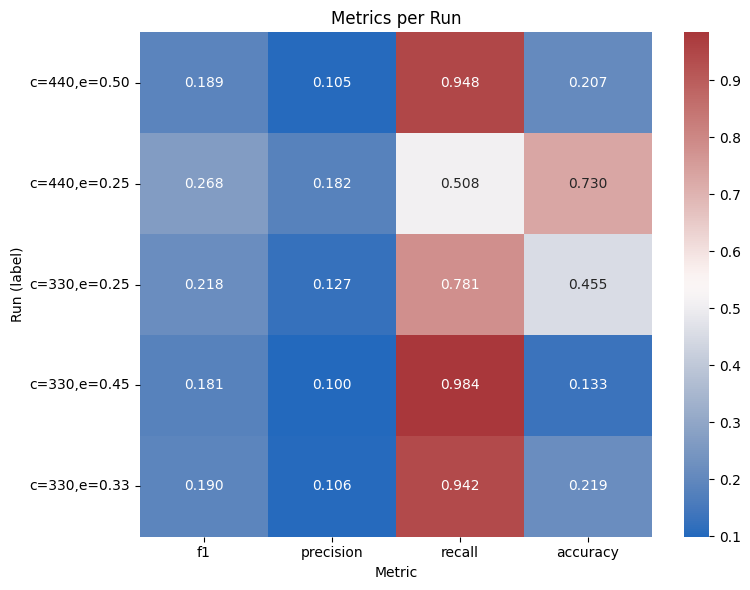

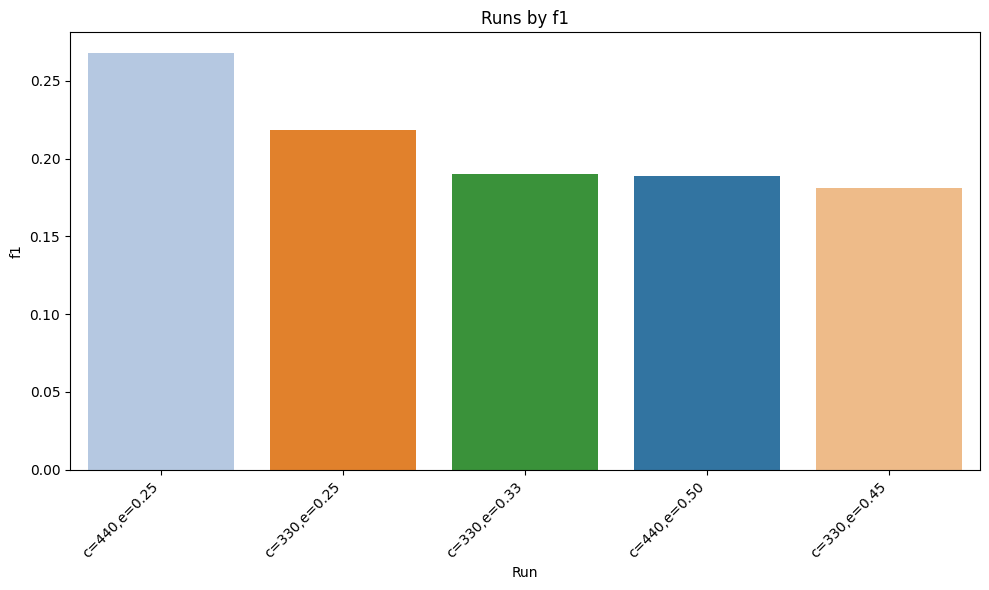

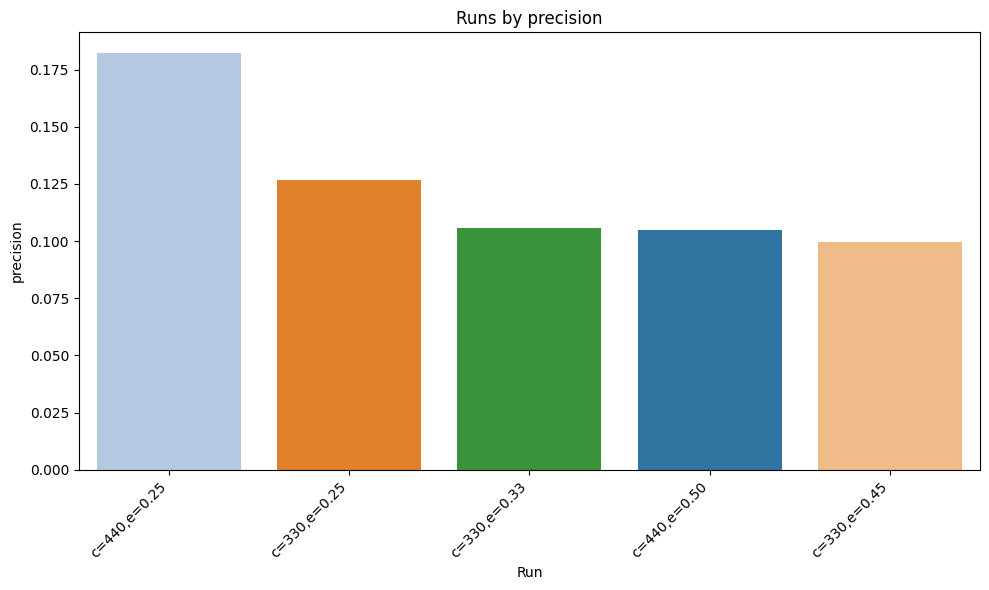

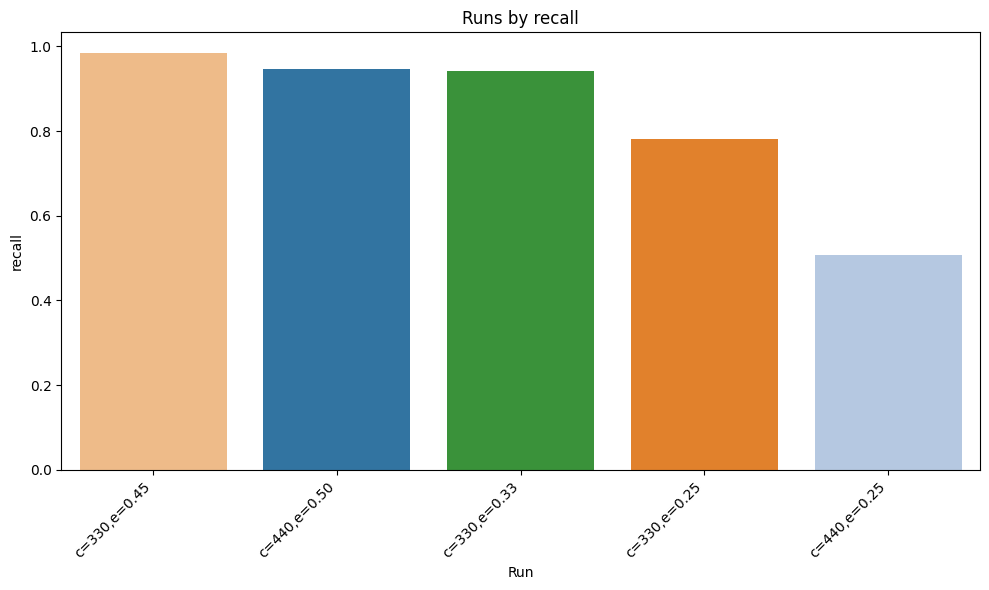

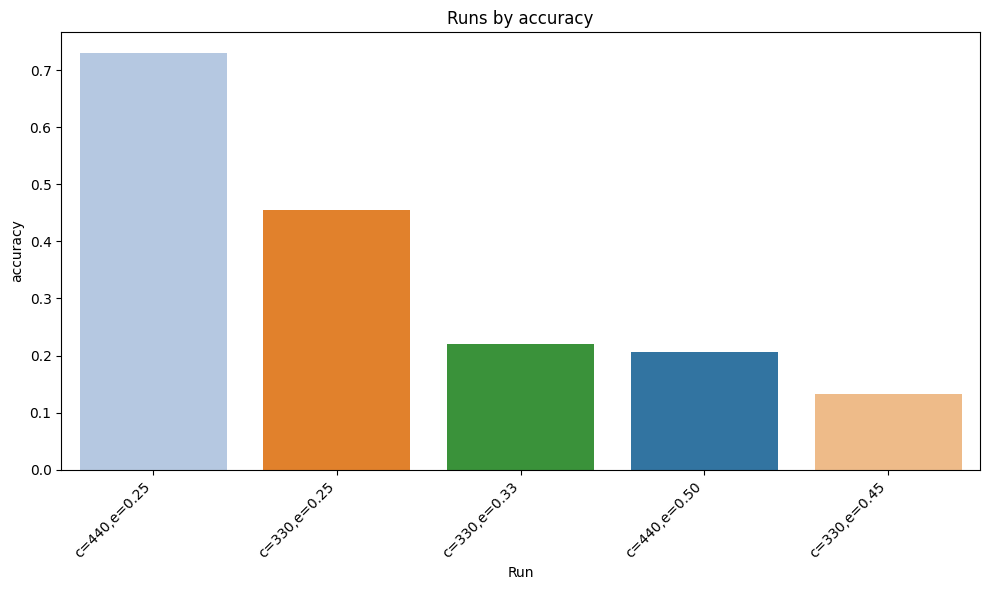

In [14]:
from shared_util.metrics.compare import plot_compare

plot_compare(
    df=df_label,
    metric_cols=["f1", "precision", "recall", "accuracy"],
    h_cmap='vlag',
    base_palette='tab20'
)

In [16]:
from shared_util.metrics.compare import print_run_compare

print_run_compare(
    df=df_label,
    metric_cols=["roc_auc", "f1", "precision", "recall", "accuracy"]
)


=== Overall ranking (by rank_sum -> overall_score) ===


,run_id,label,overall_score,rank_sum,roc_auc,f1,precision,recall,accuracy
0,13,"c=440,e=0.25",0.750,9.0,0.673558,0.267766,0.182189,0.508036,0.729728
1,14,"c=330,e=0.25",0.625,11.0,0.673558,0.218237,0.126919,0.780843,0.455317
2,16,"c=330,e=0.33",0.500,13.0,0.673558,0.190005,0.105668,0.941573,0.219444
3,12,"c=440,e=0.50",0.375,15.0,0.673558,0.188653,0.104769,0.947654,0.207028
4,15,"c=330,e=0.45",0.250,17.0,0.673558,0.180886,0.099597,0.984144,0.133352



=== Top 5 by roc_auc ===


,run_id,label,roc_auc
0,13,"c=440,e=0.25",0.673558
1,14,"c=330,e=0.25",0.673558
2,16,"c=330,e=0.33",0.673558
3,12,"c=440,e=0.50",0.673558
4,15,"c=330,e=0.45",0.673558



=== Top 5 by f1 ===


...

,run_id,label,precision
0,13,"c=440,e=0.25",0.182189
1,14,"c=330,e=0.25",0.126919
2,16,"c=330,e=0.33",0.105668
3,12,"c=440,e=0.50",0.104769
4,15,"c=330,e=0.45",0.099597



=== Top 5 by recall ===


,run_id,label,recall
4,15,"c=330,e=0.45",0.984144
3,12,"c=440,e=0.50",0.947654
2,16,"c=330,e=0.33",0.941573
1,14,"c=330,e=0.25",0.780843
0,13,"c=440,e=0.25",0.508036



=== Top 5 by accuracy ===


,run_id,label,accuracy
0,13,"c=440,e=0.25",0.729728
1,14,"c=330,e=0.25",0.455317
2,16,"c=330,e=0.33",0.219444
3,12,"c=440,e=0.50",0.207028
4,15,"c=330,e=0.45",0.133352


### Comparing Models

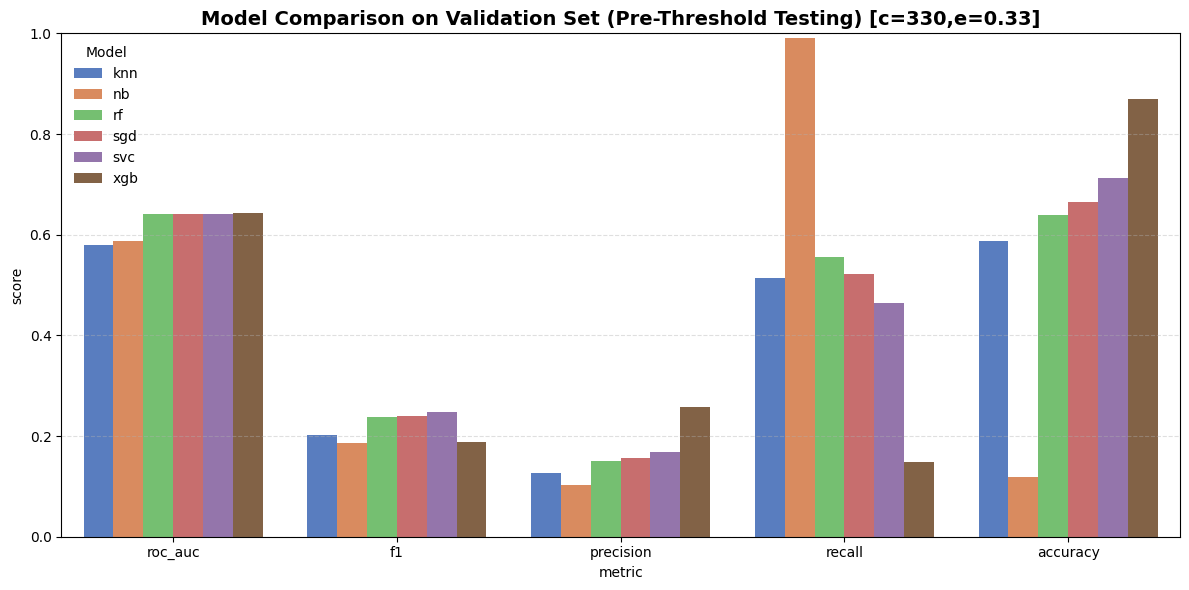

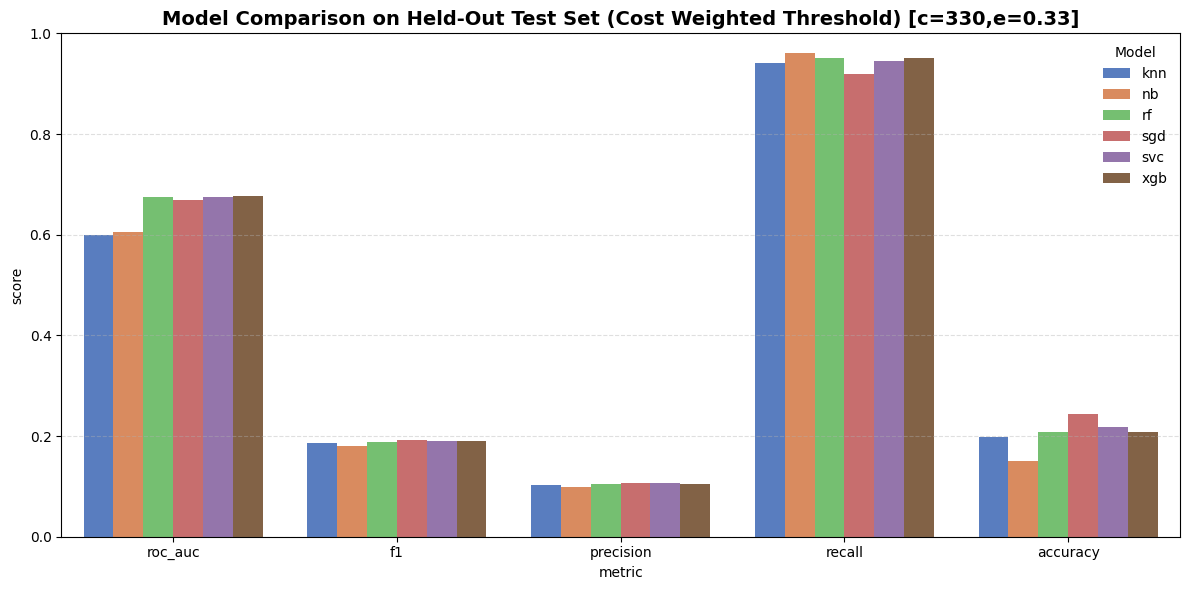

In [11]:
from shared_util.metrics.printing import summary_by
from shared_util.metrics.plotting import plot_metrics

plot_metrics(most_recent_df, METRICS_DB_ID, 'c=330,e=0.33', palette='muted')

In [84]:
print('--most recent--')


summary_by(most_recent_df, col='roc_auc')
summary_by(most_recent_df, col='recall')
summary_by(most_recent_df, col='precision')
summary_by(most_recent_df, col='est_pp_savings')
summary_by(most_recent_df, col='accuracy')


# print('--no pca--')
# summary_by_auc(results_df, plot_id=1)
# summary_by_recall(results_df)



--most recent--
Models by roc_auc


,model,roc_auc
0,xgb,0.676
6,rf,0.675
2,svc,0.674
4,sgd,0.669
8,nb,0.606


Models by recall


,model,recall
8,nb,0.960
0,xgb,0.950
6,rf,0.950
2,svc,0.945
12,knn,0.941


Models by precision


,model,precision
4,sgd,0.107
2,svc,0.106
0,xgb,0.105
6,rf,0.105
12,knn,0.103


Models by est_pp_savings


,model,est_pp_savings
4,sgd,231.760
6,rf,226.859
2,svc,226.829
0,xgb,225.353
8,nb,221.460


Models by accuracy


,model,accuracy
4,sgd,0.244
2,svc,0.217
0,xgb,0.209
6,rf,0.207
12,knn,0.198


# K-Nearest Neighbors

In [3]:
knn_pipe = ModelPipeline(
    model='knn',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    data_path='cleaned',
    plot_y_dist=False,
    random_state=42,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scaler= scaler,
    create_interactions=True,
    one_hot_ordinal=True
)

In [8]:
if GET_BASELINE:
    knn_pipe.run_baseline(
        run_smote=True,
        show_duration_info=True,
        run_undersampler=True
    )

--------SMOTE Baseline--------
roc_auc score per fold:  [0.552 0.543 0.533 0.542 0.526]
mean roc_auc score: , 0.539
-----Undersample Baseline-----
roc_auc score per fold:  [0.566 0.554 0.538 0.553 0.534]
mean roc_auc score: , 0.549
Duration: 0 hrs, 0 mins, 18.4 secs


In [ ]:
if SHOW_FEAT_IMPORTANCE:
    knn_pipe.permute_importance()

In [10]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    knn_param_dist = {
    "model__n_neighbors": np.arange(3, 31, 2),
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan", "minkowski"],
    "model__p": [1, 2],
    "model__leaf_size": np.arange(10, 50, 5)
    }
    
    knn_pipe.run_hyperparam_search(hyperparam_dist=knn_param_dist)



Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ROC_AUC (cv): 0.5899206519996217
Best params: {'model__weights': 'distance', 'model__p': 1, 'model__n_neighbors': np.int64(29), 'model__metric': 'euclidean', 'model__leaf_size': np.int64(15)}
logged hyperparameters
Duration: 0 hrs, 1 mins, 20.2 secs


In [11]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    knn_pipe.validate(
        use_local_model=True,
        show_duration_info=True,
        weights='distance',
        n_neighbors=29,
        metric='euclidean',
        leaf_size=15,
        p=1
    )
else:
    knn_pipe.validate()

Held out validation metrics: knn
ROC_AUC:     0.579132367325119
Accuracy:      0.5882006891335406
F1 score:      0.20195439739413681
Precision:     0.12570965125709652
Recall:        0.5132450331125827

Confusion matrix:

TN: 6379, FP: 4312, FN: 588, TP: 620

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.60      0.72     10691
           1       0.13      0.51      0.20      1208

    accuracy                           0.59     11899
   macro avg       0.52      0.55      0.46     11899
weighted avg       0.84      0.59      0.67     11899

Duration: 0 hrs, 0 mins, 1.5 secs


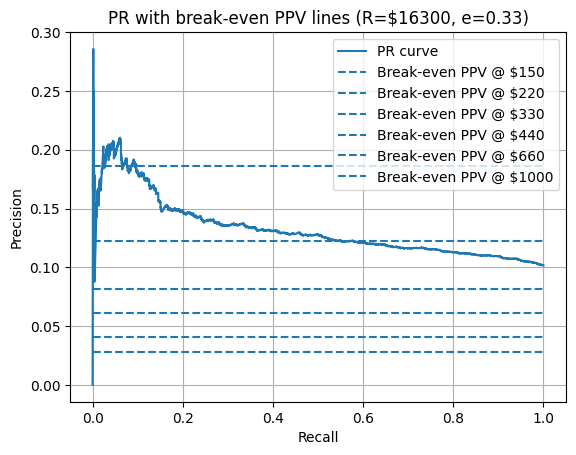

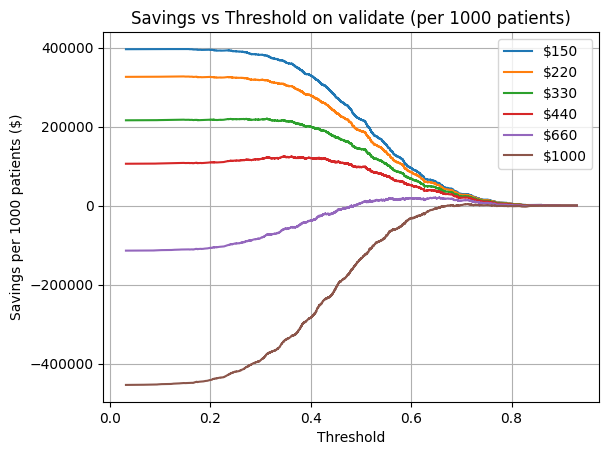

[COST] Chosen threshold: 0.3125 | PPV=0.107  Recall=0.941  FlagRate=0.890  Savings@$330=220.37 per patient
ROC_AUC:     0.6001558459969722
Accuracy:      0.1984964946363713
F1 score:      0.18584298584298584
Precision:     0.10310357958872811
Recall:        0.9409209383145091

Confusion matrix:

TN: 1267, FP: 9421, FN: 68, TP: 1083

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.12      0.21     10688
           1       0.10      0.94      0.19      1151

    accuracy                           0.20     11839
   macro avg       0.53      0.53      0.20     11839
weighted avg       0.87      0.20      0.21     11839

Duration: 0 hrs, 0 mins, 0.7 secs


In [12]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    # TODO kwargs for validate
    knn_pipe.test(
        c_m_list=m_cost_list,
        use_local_model=True,
        prefer_c_m=COST_PREF,
        show_duration_info=True,
        weights='distance',
        n_neighbors=29,
        metric='euclidean',
        leaf_size=15,
        p=1
    )
else:
    knn_pipe.test(prefer_c_m=COST_PREF,c_m_list=m_cost_list)

# Naieve-Bayes

In [13]:
nb_pipe = ModelPipeline(
    model='nb',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    data_path='cleaned',
    plot_y_dist=False,
    random_state=42,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scaler= scaler,
    create_interactions=True,
    one_hot_ordinal=True
)

In [14]:
if GET_BASELINE:
    nb_pipe.run_baseline(
        run_smote=True,
        show_duration_info=True,
        run_undersampler=True
    )
    

--------SMOTE Baseline--------
roc_auc score per fold:  [0.501 0.499 0.49  0.503 0.496]
mean roc_auc score: , 0.498
-----Undersample Baseline-----
roc_auc score per fold:  [0.608 0.504 0.517 0.5   0.59 ]
mean roc_auc score: , 0.544
Duration: 0 hrs, 0 mins, 17.1 secs


In [15]:
if SHOW_FEAT_IMPORTANCE:
    nb_pipe.permute_importance()

In [16]:
if not USE_PRE_COMPUTED_HYPERPARAMS:

    gnb_param_dist = {
        "model__var_smoothing": np.logspace(-12, -6, 20)
    }

    nb_pipe.run_hyperparam_search(hyperparam_dist=gnb_param_dist)

    

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best ROC_AUC (cv): 0.5653596489801007
Best params: {'model__var_smoothing': np.float64(1e-06)}
logged hyperparameters
Duration: 0 hrs, 0 mins, 48.1 secs


In [17]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    nb_pipe.validate(
        use_local_model=True,
        show_duration_info=True,
        var_smoothing=1e-06,
    )
else:
    nb_pipe.validate()

Held out validation metrics: nb
ROC_AUC:     0.5880641078929421
Accuracy:      0.11900159677283806
F1 score:      0.18603928876465564
Precision:     0.10264758803872848
Recall:        0.9917218543046358

Confusion matrix:

TN: 218, FP: 10473, FN: 10, TP: 1198

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.02      0.04     10691
           1       0.10      0.99      0.19      1208

    accuracy                           0.12     11899
   macro avg       0.53      0.51      0.11     11899
weighted avg       0.87      0.12      0.05     11899



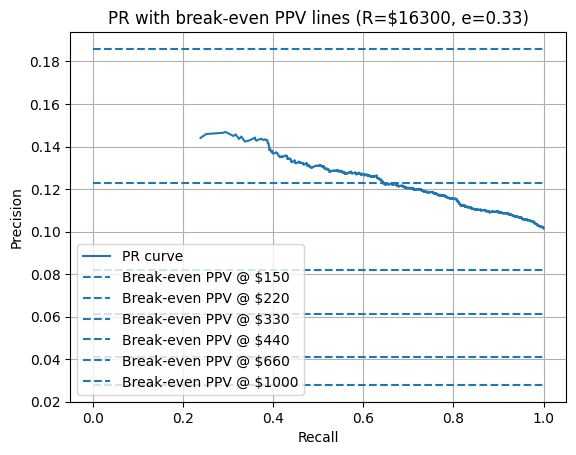

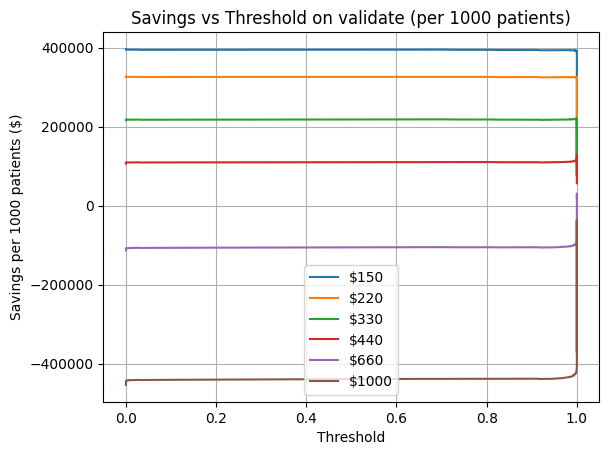

[COST] Chosen threshold: 0.9996 | PPV=0.105  Recall=0.978  FlagRate=0.947  Savings@$330=221.46 per patient
ROC_AUC:     0.6055966775181176
Accuracy:      0.14984373680209478
F1 score:      0.180040733197556
Precision:     0.09933477166486875
Recall:        0.9600347523892268

Confusion matrix:

TN: 669, FP: 10019, FN: 46, TP: 1105

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.06      0.12     10688
           1       0.10      0.96      0.18      1151

    accuracy                           0.15     11839
   macro avg       0.52      0.51      0.15     11839
weighted avg       0.85      0.15      0.12     11839



In [19]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    nb_pipe.test(
        use_local_model=True,
        show_duration_info=True,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
        var_smoothing=1e-06,

    )
else:
    nb_pipe.test(prefer_c_m=COST_PREF,c_m_list=m_cost_list)

--------SMOTE Baseline--------
roc_auc score per fold:  [0.59  0.591 0.585 0.593 0.589]
mean roc_auc score: , 0.590
-----Undersample Baseline-----
roc_auc score per fold:  [0.647 0.638 0.63  0.658 0.64 ]
mean roc_auc score: , 0.643
Duration: 0 hrs, 0 mins, 26.8 secs


----------Running hyperparameter search for model: lgbm----------
Fitting 5 folds for each of 30 candidates, totalling 150 fits


ValueError: 
All the 150 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
150 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Mike\Documents\GitHub\Eaton_633_Project\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Mike\Documents\GitHub\Eaton_633_Project\.venv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Mike\Documents\GitHub\Eaton_633_Project\.venv\Lib\site-packages\imblearn\pipeline.py", line 526, in fit
    self._final_estimator.fit(Xt, yt, **last_step_params["fit"])
  File "c:\Users\Mike\Documents\GitHub

# Random Forest

After reading (Liu, V. et al.) and (Mahmoud, M. et al.) I decided to begin expirementing with random forest models instead of logistic regression models.

In other studies, random forest models were shown to out perform logsitic regression and support vector models likely due to the mix of tabular, categorical, and numerical features

### Define Pipeline

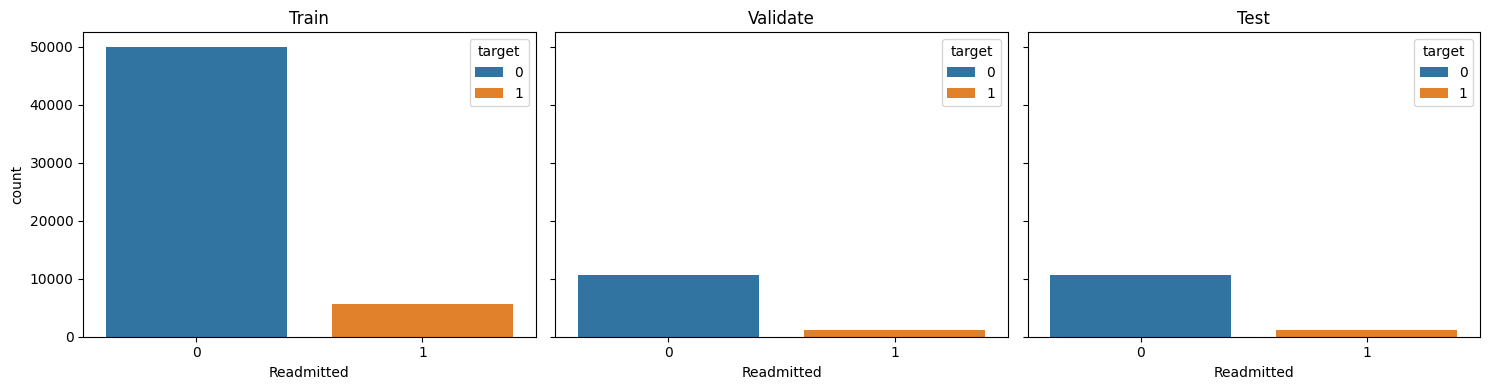

In [8]:

model = 'rf' # Random Forest


model_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,        
    data_path='cleaned',             # csv file name where the data is
    plot_y_dist=True,                # show the target distribution between splits   
    random_state=42,
    log_transform_cols=np.array([]), # no need to transform for tree models
    model=model,
    scaler=None,
    group_by_col='patient_nbr',
    create_interactions=False, # no interaction terms for tree models
    one_hot_ordinal=False, # no one-hot encoding for tree models, use int based grouping
)

### Baseline

Get a baseline before looking at feature importance or hyperparameter tuning

We can use this baseline to check class imbalance approach methods, as well as to get a sense if this model can learn anything from the engineered features

In [3]:
if GET_BASELINE:
    model_pipe.run_baseline(
        run_smote=True,
        run_undersampler=True,
        show_duration_info=True,
    )

After several iterations of data cleaning tweaks, baseline SMOTE is performing significantly better with mean ROC of ~0.59

However the random under sampler still outperforms with a mean AUC_ROC of ~0.63

SMOTE performed worse than under sampling so we will stick with under sampling going forward

A mean ROC_AUC score of 0.630 implies that the model has learned something from the data so we will continue analysis.

### Feature Importance

- Tree impurity based importance is naturaly skewed to favor continuous features
- Permutation importance is model agnostic, is uneffected by the large class imbalance, and is not effected by the under sampling technique used

,feature,importance_mean,importance_std
4,number_inpatient,0.069337,0.007399
5,number_diagnoses,0.003936,0.001551
3,num_medications,0.002776,0.004569
1,num_lab_procedures,0.002603,0.000981
13,diag1_group_respiratory,0.002541,0.001461
0,time_in_hospital,0.002358,0.001697
35,specialty_cat_cardiology,0.002161,0.000345
59,v_emergency_group_several,0.001551,0.000569
49,admit_type_group_elective,0.001487,0.001395
56,v_emergency_group_few,0.001238,0.001340


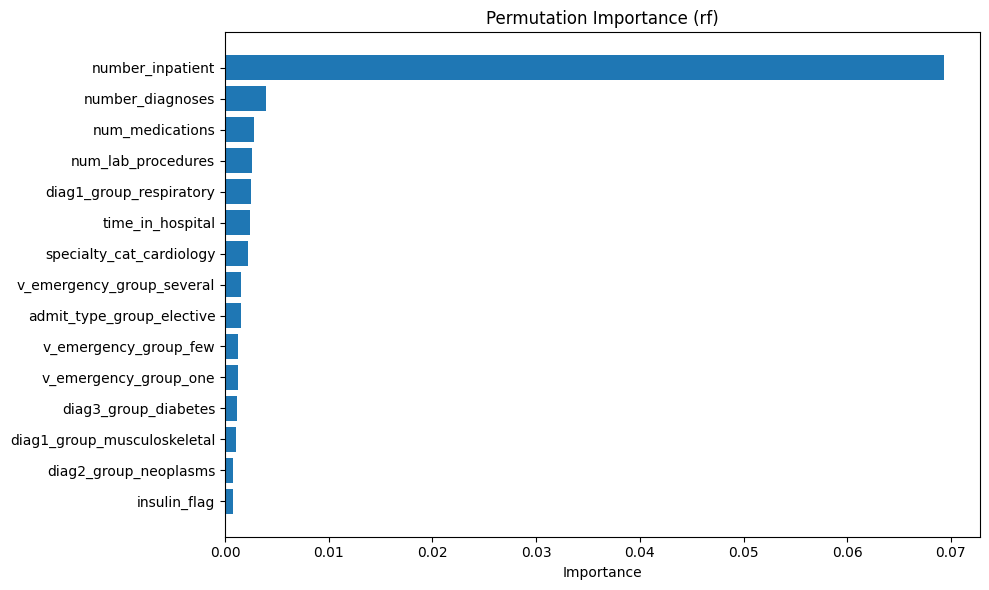

Duration: 0 hrs, 0 mins, 46.4 secs


In [4]:
if SHOW_FEAT_IMPORTANCE:
    model_pipe.permute_importance(
        print_num=15,
        plot=True,
        show_duration_info=True
    )

In [5]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    param_grid = {
            'model__n_estimators': [100, 200, 500],
            'model__max_depth': [None, 10, 20, 30],
            'model__min_samples_split': [2, 5, 10, 15, 20],
            'model__min_samples_leaf': [1, 2, 4, 6, 10],
            'model__max_features': ['sqrt', 'log2', 0.2, 0.5],
            'model__class_weight': [None, 'balanced'],
            'model__bootstrap': [True, False],
            'model__oob_score': [True, False]
        }

    model_pipe.run_hyperparam_search(
        hyperparam_dist=param_grid,
        param_scoring='roc_auc',
        n_iter=30,
        n_jobs=-1,
        refit=True,
        show_duration_info=True
    )

### Validate

In [9]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    model_pipe.validate(
        show_duration_info=True,
        use_local_model=True,
        oob_score = True,
        n_estimators = 200,
        min_samples_split = 15,
        min_samples_leaf = 6,
        max_features = 'log2',
        max_depth = 10,
        class_weight = None,
        bootstrap = True
    )

else:
    model_pipe.validate(
        show_duration_info=False,
        use_local_model=False
    )

Held out validation metrics: rf
ROC_AUC:     0.6412181503164449
Accuracy:      0.6385410538700731
F1 score:      0.2378167641325536
Precision:     0.1512965050732807
Recall:        0.5554635761589404

Confusion matrix:

TN: 6927, FP: 3764, FN: 537, TP: 671

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.65      0.76     10691
           1       0.15      0.56      0.24      1208

    accuracy                           0.64     11899
   macro avg       0.54      0.60      0.50     11899
weighted avg       0.85      0.64      0.71     11899

connected to database
Duration: 0 hrs, 0 mins, 2.9 secs


### Test

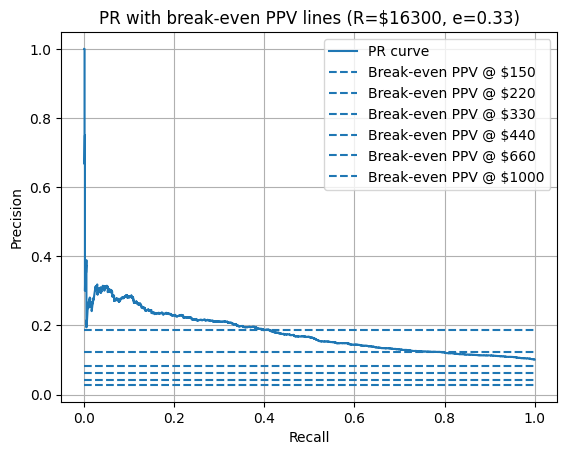

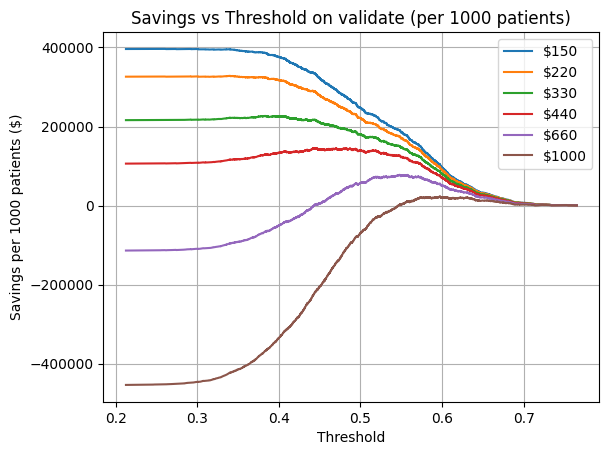

[COST] Chosen threshold: 0.3829 | PPV=0.109  Recall=0.952  FlagRate=0.888  Savings@$330=226.86 per patient
ROC_AUC:     0.6746510779483605
Accuracy:      0.2073654869499113
F1 score:      0.18907708261320427
Precision:     0.10498032818347568
Recall:        0.950477845351868

Confusion matrix:

TN: 1361, FP: 9327, FN: 57, TP: 1094

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.13      0.22     10688
           1       0.10      0.95      0.19      1151

    accuracy                           0.21     11839
   macro avg       0.53      0.54      0.21     11839
weighted avg       0.88      0.21      0.22     11839



In [10]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    model_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_local_model=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
        oob_score = True,
        n_estimators = 200,
        min_samples_split = 15,
        min_samples_leaf = 6,
        max_features = 'log2',
        max_depth = 10,
        class_weight = None,
        bootstrap = True
    )
else:
    model_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_local_model=False,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
    )

# Stochastic Gradient Descent Classifier

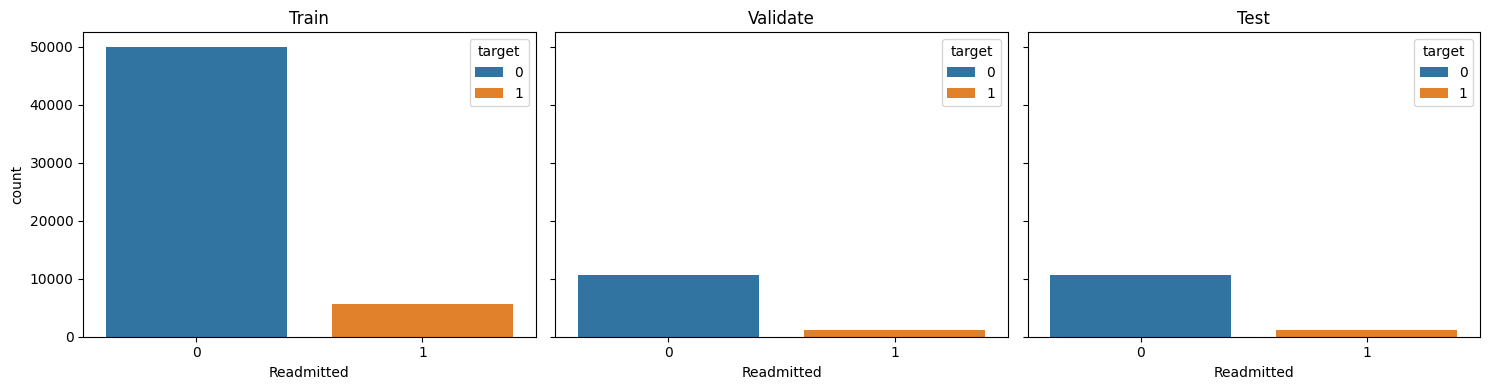

In [11]:
model = 'sgd' #SGDClassifier


sgd_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    model=model,
    scaler=scaler,
    use_pca=PCA,
    create_interactions=True,
    one_hot_ordinal=True
)



### Feature Importance

In [12]:
if not PCA and SHOW_FEAT_IMPORTANCE:
    sgd_pipe.permute_importance()

### Baseline

In [13]:
if SHOW_FEAT_IMPORTANCE:
    sgd_pipe.run_baseline() # all true

### Hyperparameter Search

In [14]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    sgd_param_grid = {
        "model__loss": ["log_loss", "modified_huber", "hinge", "squared_hinge"],
        "model__penalty": ["l2", "l1", "elasticnet"],
        "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
        "model__l1_ratio": [0.1, 0.5, 0.9],
        "model__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
        "model__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
        "model__max_iter": [100, 500, 1000],
        "model__tol": [1e-3, 1e-4],
        "model__class_weight": [None, "balanced"],
        "model__average": [False, True, 5, 10],
        "model__shuffle": [True],
    }

    sgd_pipe.run_hyperparam_search(hyperparam_dist=sgd_param_grid)

### Validate

In [15]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    sgd_pipe.validate(
        show_duration_info=True,
        use_local_model=True,
        tol=.0001,
        shuffle=True,
        penalty='l1',
        max_iter=500,
        loss='modified_huber',
        learning_rate='invscaling',
        l1_ratio=0.9,
        eta0=.003,
        class_weight=None,
        average=10,
        alpha=.001
        )
else:
    sgd_pipe.validate(show_duration_info=False)

Held out validation metrics: sgd
ROC_AUC:     0.6419034144582836
Accuracy:      0.6640053786032439
F1 score:      0.23992395437262357
Precision:     0.15572556762092793
Recall:        0.5223509933774835

Confusion matrix:

TN: 7270, FP: 3421, FN: 577, TP: 631

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.68      0.78     10691
           1       0.16      0.52      0.24      1208

    accuracy                           0.66     11899
   macro avg       0.54      0.60      0.51     11899
weighted avg       0.85      0.66      0.73     11899

Duration: 0 hrs, 0 mins, 1.8 secs


### Test

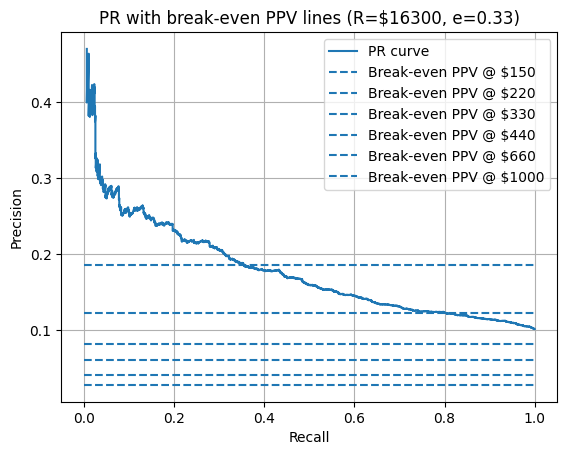

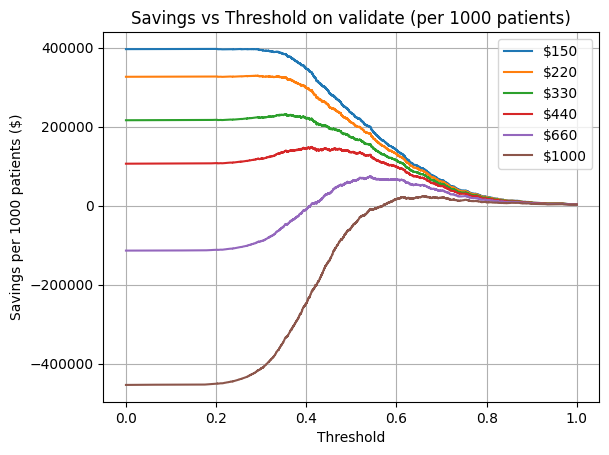

[COST] Chosen threshold: 0.3539 | PPV=0.112  Recall=0.935  FlagRate=0.844  Savings@$330=231.76 per patient
ROC_AUC:     0.6694076551501689
Accuracy:      0.24402398851254328
F1 score:      0.19136248644741596
Precision:     0.10678632651003328
Recall:        0.9200695047784535

Confusion matrix:

TN: 1830, FP: 8858, FN: 92, TP: 1059

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.17      0.29     10688
           1       0.11      0.92      0.19      1151

    accuracy                           0.24     11839
   macro avg       0.53      0.55      0.24     11839
weighted avg       0.87      0.24      0.28     11839

Duration: 0 hrs, 0 mins, 0.6 secs


In [16]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    sgd_pipe.test(
        use_f2_threshold=False,
        show_plot=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
        show_duration_info=True,
        use_local_model=True,
        tol=.0001,
        shuffle=True,
        penalty='l1',
        max_iter=500,
        loss='modified_huber',
        learning_rate='invscaling',
        l1_ratio=0.9,
        eta0=.003,
        class_weight=None,
        average=10,
        alpha=.001
    )

else:


    sgd_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_local_model=False,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
    )

# Support Vector Classifier

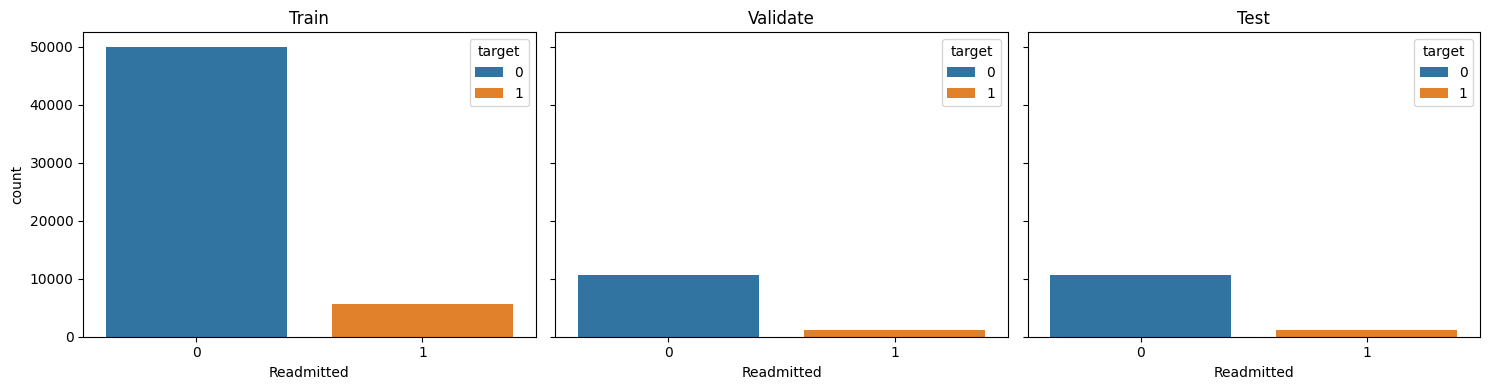

In [17]:

svc_pipe = ModelPipeline(
    model='svc',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scaler=scaler,
    use_pca=PCA,
    create_interactions=True,
    one_hot_ordinal=True
)

### Baseline

In [18]:
if GET_BASELINE:
    svc_pipe.run_baseline(run_smote=False) # smote did not complete after ~6 hours

### Feature Importance

In [19]:
# slow
# svc_pipe.permute_importance()

### Hyperparameter Search

In [20]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    from scipy.stats import loguniform
    # slow

    # limited param search due to computation time
    svc_param_grid = {
        "model__C": loguniform(1e-3, 1e3),
        "model__gamma": [0.0001, 0.001, 0.01, 0.1, 1],     
    }

    svc_pipe.run_hyperparam_search(hyperparam_dist=svc_param_grid)

### Validate

In [21]:
if USE_PRE_COMPUTED_HYPERPARAMS:
        svc_pipe.validate(
        use_local_model=True,
        C=2.3973382079286494,
        gamma=.001
    )
else:
    svc_pipe.validate()

Held out validation metrics: svc
ROC_AUC:     0.6411854744443708
Accuracy:      0.7122447264476006
F1 score:      0.24714160070360597
Precision:     0.16826347305389222
Recall:        0.4652317880794702

Confusion matrix:

TN: 7913, FP: 2778, FN: 646, TP: 562

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.74      0.82     10691
           1       0.17      0.47      0.25      1208

    accuracy                           0.71     11899
   macro avg       0.55      0.60      0.53     11899
weighted avg       0.85      0.71      0.76     11899



### Test

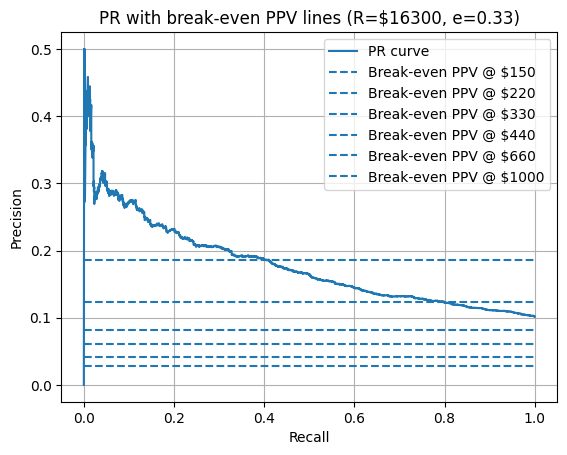

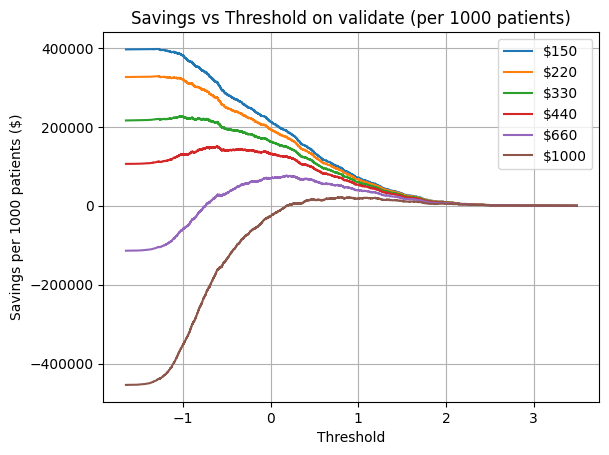

[COST] Chosen threshold: -1.0260 | PPV=0.109  Recall=0.946  FlagRate=0.878  Savings@$330=226.83 per patient
ROC_AUC:     0.6741491224761598
Accuracy:      0.2174170115719233
F1 score:      0.1901931649331352
Precision:     0.10573372206025267
Recall:        0.945264986967854

Confusion matrix:

TN: 1486, FP: 9202, FN: 63, TP: 1088

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.14      0.24     10688
           1       0.11      0.95      0.19      1151

    accuracy                           0.22     11839
   macro avg       0.53      0.54      0.22     11839
weighted avg       0.88      0.22      0.24     11839



In [22]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    svc_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
        use_local_model=True,
        C=2.3973382079286494,
        gamma=.001
    )
else:
    svc_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
    )

# XGBoost

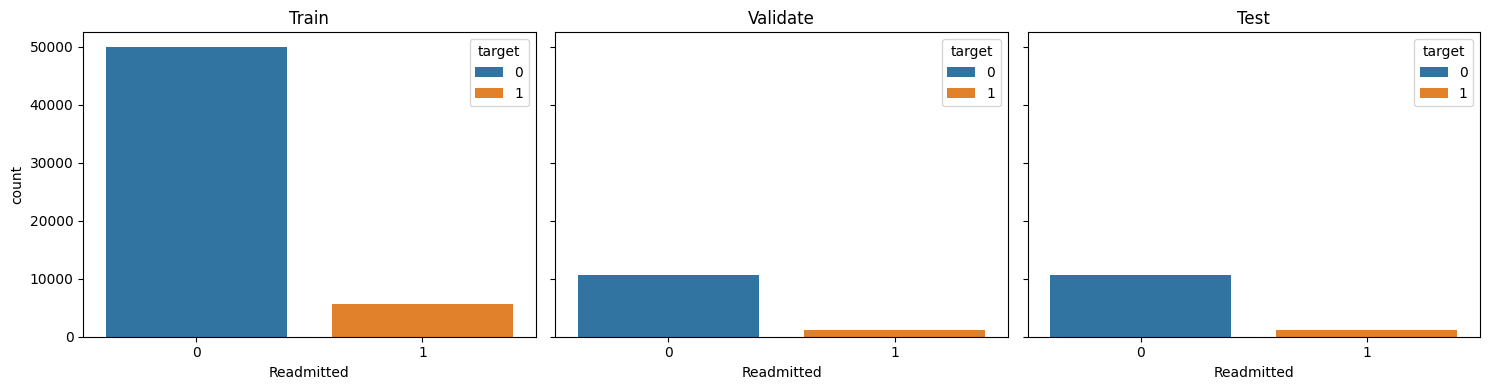

In [23]:
xgb_pipe = ModelPipeline(
    model='xgb',
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log=UPDATE_DATABASE,
    create_interactions=False,
    log_transform_cols=np.array([]),
    use_pca=PCA,
    scaler=None,
    one_hot_ordinal=False,
    resample=False # handled by hyperparameters
)

In [24]:
if GET_BASELINE:
    xgb_pipe.run_baseline()

In [25]:
if not PCA and SHOW_FEAT_IMPORTANCE:
    xgb_pipe.permute_importance()

In [26]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    param_dist = {
        'model__max_depth': [3,4,5],
        'model__min_child_weight': [1,2,4],
        'model__subsample': [0.6,0.8,1.0],
        'model__colsample_bytree': [0.6,0.8,1.0],
        'model__gamma': [0,1,3],
        'model__learning_rate': [0.02, 0.05, 0.1],
        'model__scale_pos_weight': [1,2,4,6,8,10]
    }

    xgb_pipe.run_hyperparam_search(
        hyperparam_dist=param_dist
    )

In [27]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    xgb_pipe.validate(
        use_local_model=True,
        subsample=0.6,
        scale_pos_weight=4,
        min_child_weight=2,
        max_depth=3,
        learning_rate = 0.1,
        gamma = 0,
        colsample_bytree=0.8
    )
else:
    xgb_pipe.validate()

Held out validation metrics: xgb
ROC_AUC:     0.6437720174981617
Accuracy:      0.8701571560635347
F1 score:      0.1889763779527559
Precision:     0.2582496413199426
Recall:        0.1490066225165563

Confusion matrix:

TN: 10174, FP: 517, FN: 1028, TP: 180

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93     10691
           1       0.26      0.15      0.19      1208

    accuracy                           0.87     11899
   macro avg       0.58      0.55      0.56     11899
weighted avg       0.84      0.87      0.85     11899



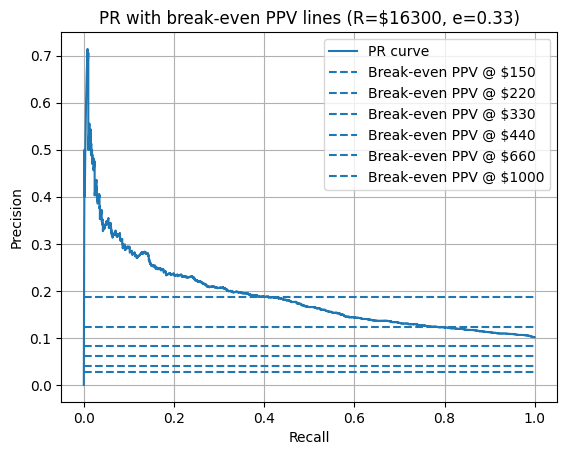

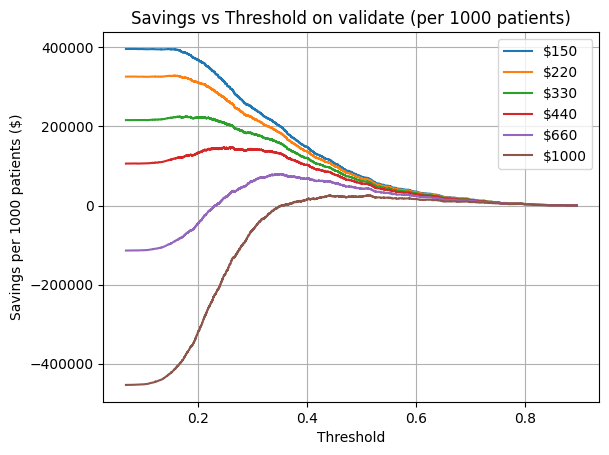

[COST] Chosen threshold: 0.1797 | PPV=0.108  Recall=0.951  FlagRate=0.891  Savings@$330=225.35 per patient
ROC_AUC:     0.6760256637030024
Accuracy:      0.20897035222569474
F1 score:      0.1893880377391154
Precision:     0.10517208229186695
Recall:        0.950477845351868

Confusion matrix:

TN: 1380, FP: 9308, FN: 57, TP: 1094

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.13      0.23     10688
           1       0.11      0.95      0.19      1151

    accuracy                           0.21     11839
   macro avg       0.53      0.54      0.21     11839
weighted avg       0.88      0.21      0.22     11839



In [28]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    xgb_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
        use_local_model=True,
        subsample=0.6,
        scale_pos_weight=4,
        min_child_weight=2,
        max_depth=3,
        learning_rate = 0.1,
        gamma = 0,
        colsample_bytree=0.8
    )

else:

    xgb_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_local_model=False,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
    )

In [29]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    import matplotlib.pyplot as plt
    from shared_util.dataio import load_csv



    df = load_csv('cleaned')
    from shared_util.split import group_split

    X_train, X_validate, X_test, y_train, y_validate, y_test = group_split(df)
    plt.hist(xgb_pipe.randomized_search.best_estimator_.predict_proba(X_validate)[:,1], bins=50) #type: ignore
    plt.show()


# Data Exploration

In [30]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
# fetch dataset 
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 
  
# data (as pandas dataframes) 
X: pd.DataFrame = diabetes_130_us_hospitals_for_years_1999_2008.data.features  # type: ignore
y :pd.DataFrame = diabetes_130_us_hospitals_for_years_1999_2008.data.targets.copy()  # type: ignore

In [32]:
from shared_util.dataio import load_csv
_df = load_csv('diabetic_data')
_df = _df.reset_index().rename(columns={'index': 'encounter_id'})
_df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [33]:
print(f'csv: len={len(_df)}')
print(f'python import: len={len(X)}')
print(f'csv: len={len(_df.columns)}')
print(f'python import: len={len(X.columns)}')

csv: len=101766
python import: len=101766
csv: len=50
python import: len=47


data imported from the pip package is missing patient_nbr and encounter_id

In [34]:
_df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [35]:
_df['patient_nbr'].value_counts()

patient_nbr
88785891     40
43140906     28
88227540     23
23199021     23
1660293      23
             ..
3327282       1
98427861      1
92519352      1
101002446     1
104672268     1
Name: count, Length: 71518, dtype: int64

Multiple repeated patient encounters, one patient number shows up 40 times

### Target Distribution

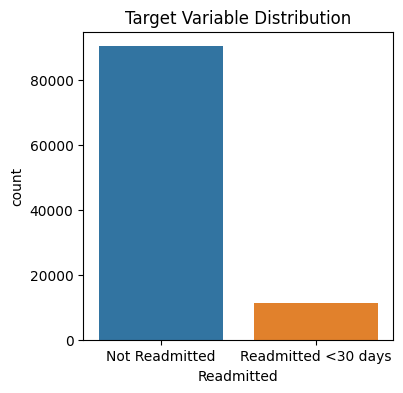

In [36]:
# target distribution

plt.figure(figsize=(4,4))

y['readmitted'] = y['readmitted'].astype('string')

y['target'] = (y['readmitted'] == '<30').astype(int)


label_map = {0: 'Not Readmitted', 1: 'Readmitted <30 days'}


y_plt = y['target'].map(label_map)


sns.countplot(x=y_plt, hue=y_plt)


plt.title('Target Variable Distribution')
plt.xlabel('Readmitted')
plt.ylabel('count')

plt.show()

In [37]:
print(f'Percent Readmitted In under 30 days: {y['target'].mean()*100:.2f}%')

Percent Readmitted In under 30 days: 11.16%


The target class is extremely imbalanced. This will be addressed later on with an over or under sampling technique.

<HR>

### Missing Data

,n_missing,pct_missing
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02
time_in_hospital,0,0.00


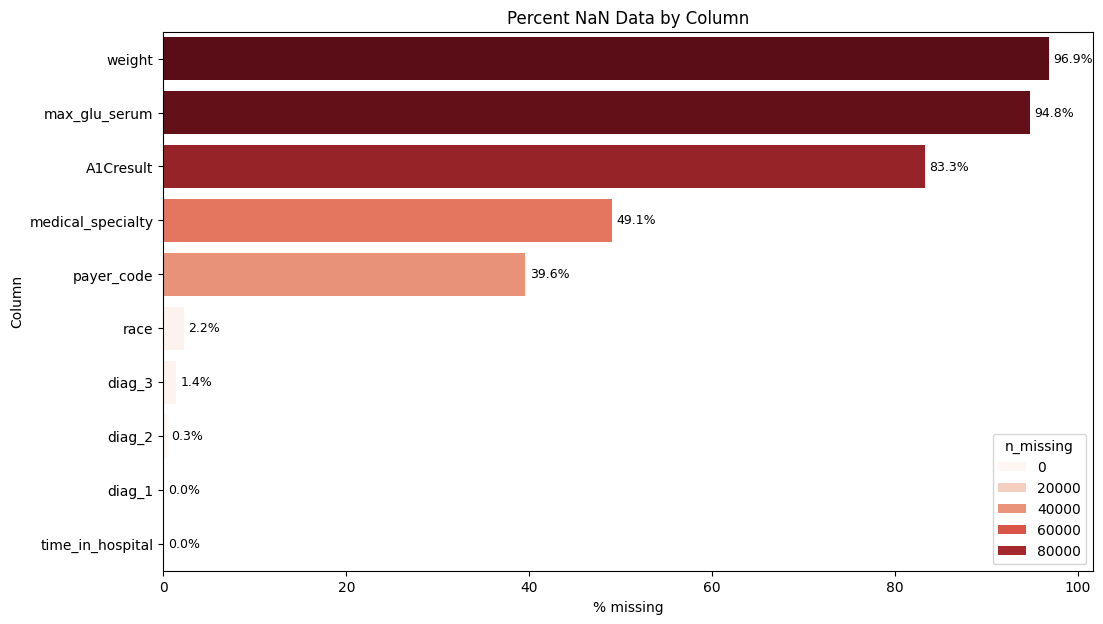

In [38]:
missing = X.isna().sum().to_frame(name='n_missing')
missing['pct_missing'] = (missing['n_missing'] / len(X) * 100).round(2)
missing = missing.sort_values('pct_missing', ascending=False)
display(missing.head(10))

top_missing = missing.head(10).reset_index().rename(columns={'index':'column'})

plt.figure(figsize=(12,7))


sns.barplot(data=top_missing, x='pct_missing', y='column', palette='Reds', hue='n_missing' )
plt.title('Percent NaN Data by Column')
plt.xlabel('% missing')
plt.ylabel('Column')

for i, pct in enumerate(top_missing['pct_missing']):
    plt.text(pct + 0.5, i, f'{pct:.1f}%', va='center', fontsize=9)

plt.show()

Weight, as we knew, is extremely sparse. As stated in Strack et al. we can also see that A1CResult has ~83% missing, the focus of their study.

Payer Code shows almost 40% missing, and will be dropped later on as not being useful in prediction.

Medical specialy is ~50% missing but is kept as a decent indicator of readmission.

### Continuous Column Inspection

In [39]:
# statistical summary of continuous columns

cont_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

num_df = X[cont_cols].dropna()

num_df.describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


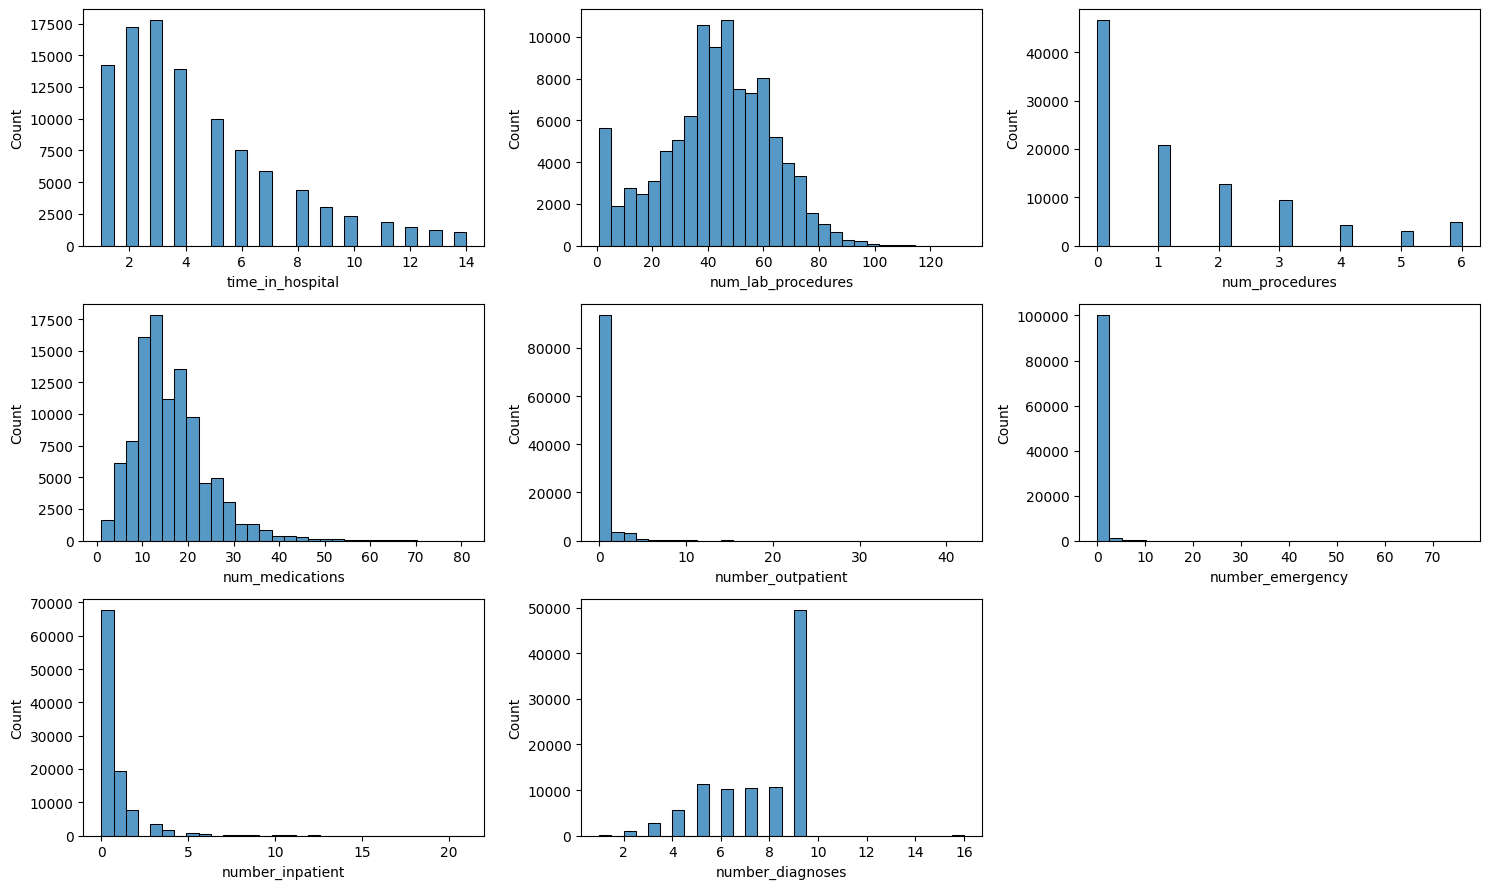

In [40]:
import math

def cont_hist_plots(num_feats_df):
    cols = num_feats_df.columns.tolist()
    n = len(cols)
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        data = num_feats_df[col].dropna()
        bins = 30
        sns.histplot(data, bins=bins, kde=False, ax=ax, color="C0", stat="count") # type: ignore

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

cont_hist_plots(num_df)


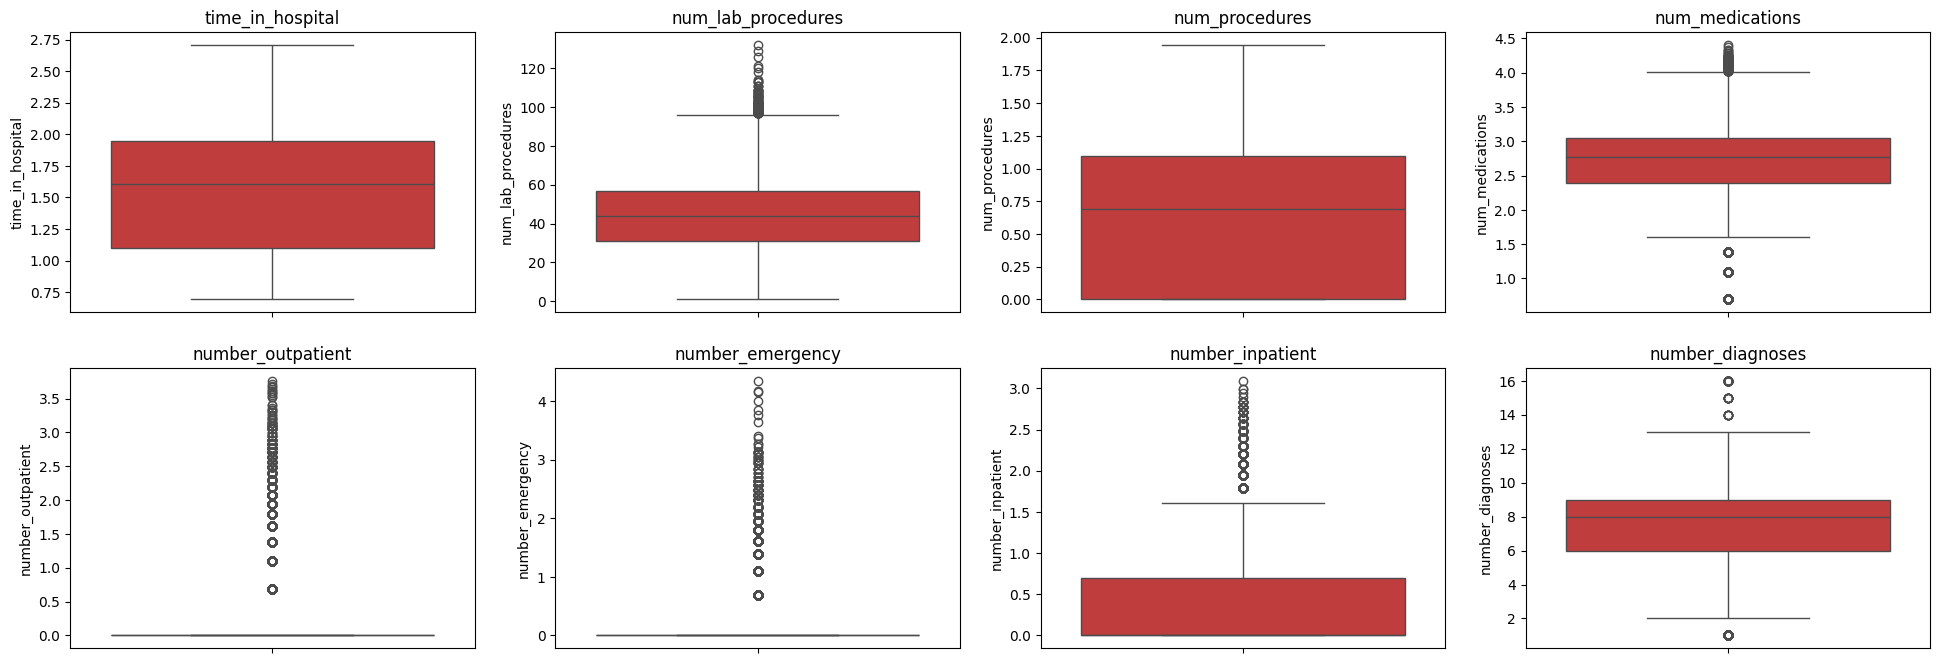

In [41]:
# bar plots, looking for outliers

num_df_log = num_df.copy()

# linear models will transform these columns in pre processing pipeline
log_transform_cols = np.array(
    ['number_outpatient', 'number_inpatient', 'number_emergency', 
     'num_medications', 'num_procedures', 'time_in_hospital'
     ])



num_df_log[log_transform_cols] = np.log1p(num_df_log[log_transform_cols].dropna())

cols = num_df_log.columns.to_list()


# 2) compact boxplots (quickly highlights outliers)
fig, axes = plt.subplots(2,4, figsize=(len(cols)*3, 8))
axes = axes.flatten()
if len(cols) == 1:
    axes = [axes]
for ax, col in zip(axes, cols):
    sns.boxplot(y=num_df_log[col], ax=ax, color='C3')
    ax.set_title(col)
    ax.set_xlabel('')

plt.show()

In [42]:
# transform cols
df = _df.copy()
df['readmitted'] = (df['readmitted'] == '<30').astype(int)
df[cont_cols] = np.log1p(df[cont_cols])

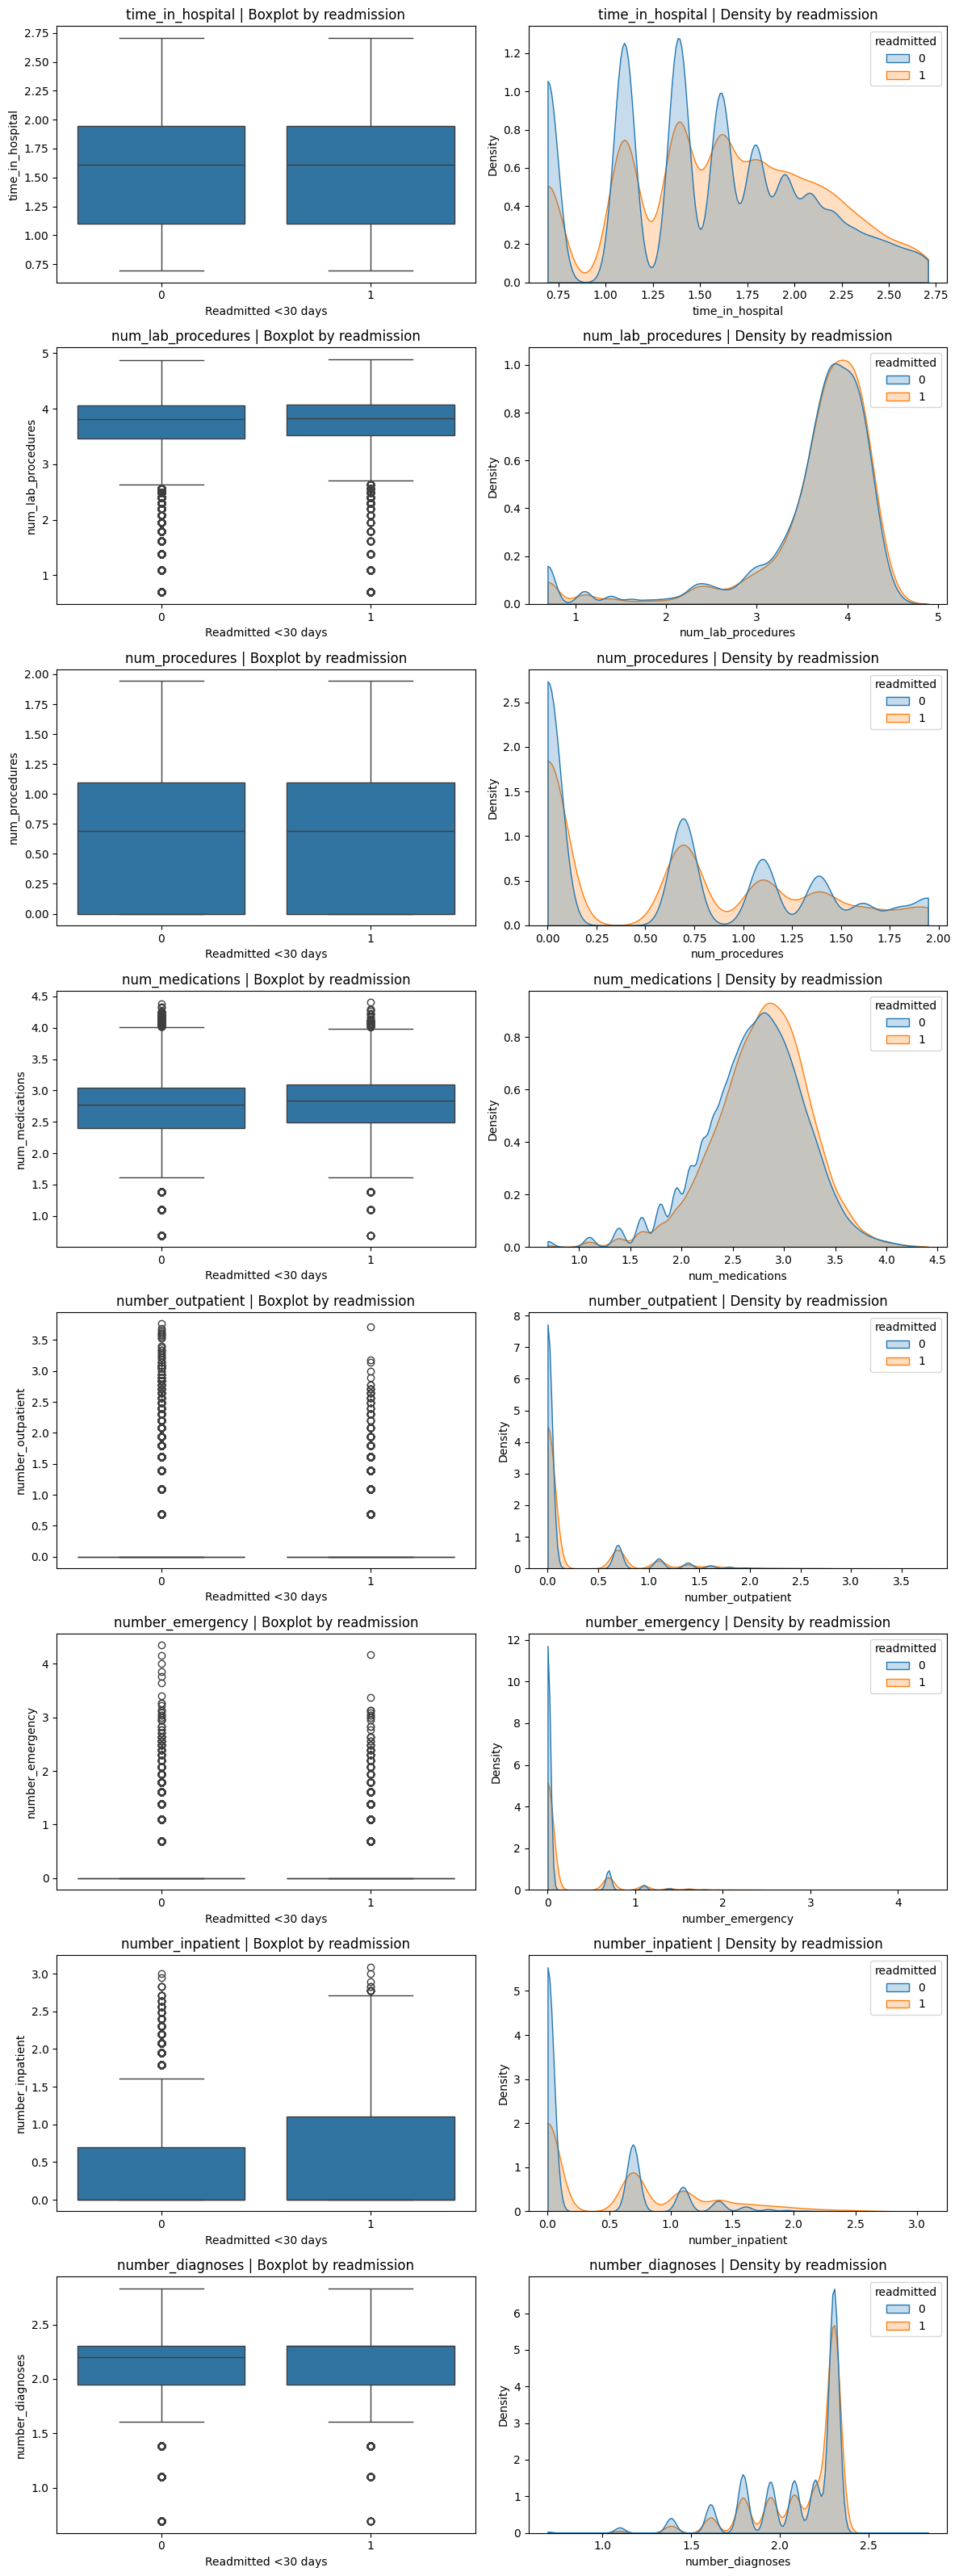

In [43]:

fig, axes = plt.subplots(len(cont_cols), 2, figsize=(12, 4 * len(cont_cols)))
for i, col in enumerate(cont_cols):
    sns.boxplot(
        data=df,
        x="readmitted",
        y=col,
        ax=axes[i, 0],
        showfliers=True  
    )
    axes[i, 0].set_title(f"{col} | Boxplot by readmission")
    axes[i, 0].set_xlabel("Readmitted <30 days")
    axes[i, 0].set_ylabel(col)

    sns.kdeplot(
        data=df,
        x=col,
        hue="readmitted",
        common_norm=False,  
        fill=True,
        ax=axes[i, 1],
        cut=0,
    )
    axes[i, 1].set_title(f"{col} | Density by readmission")
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel("Density")

plt.tight_layout()
plt.show()

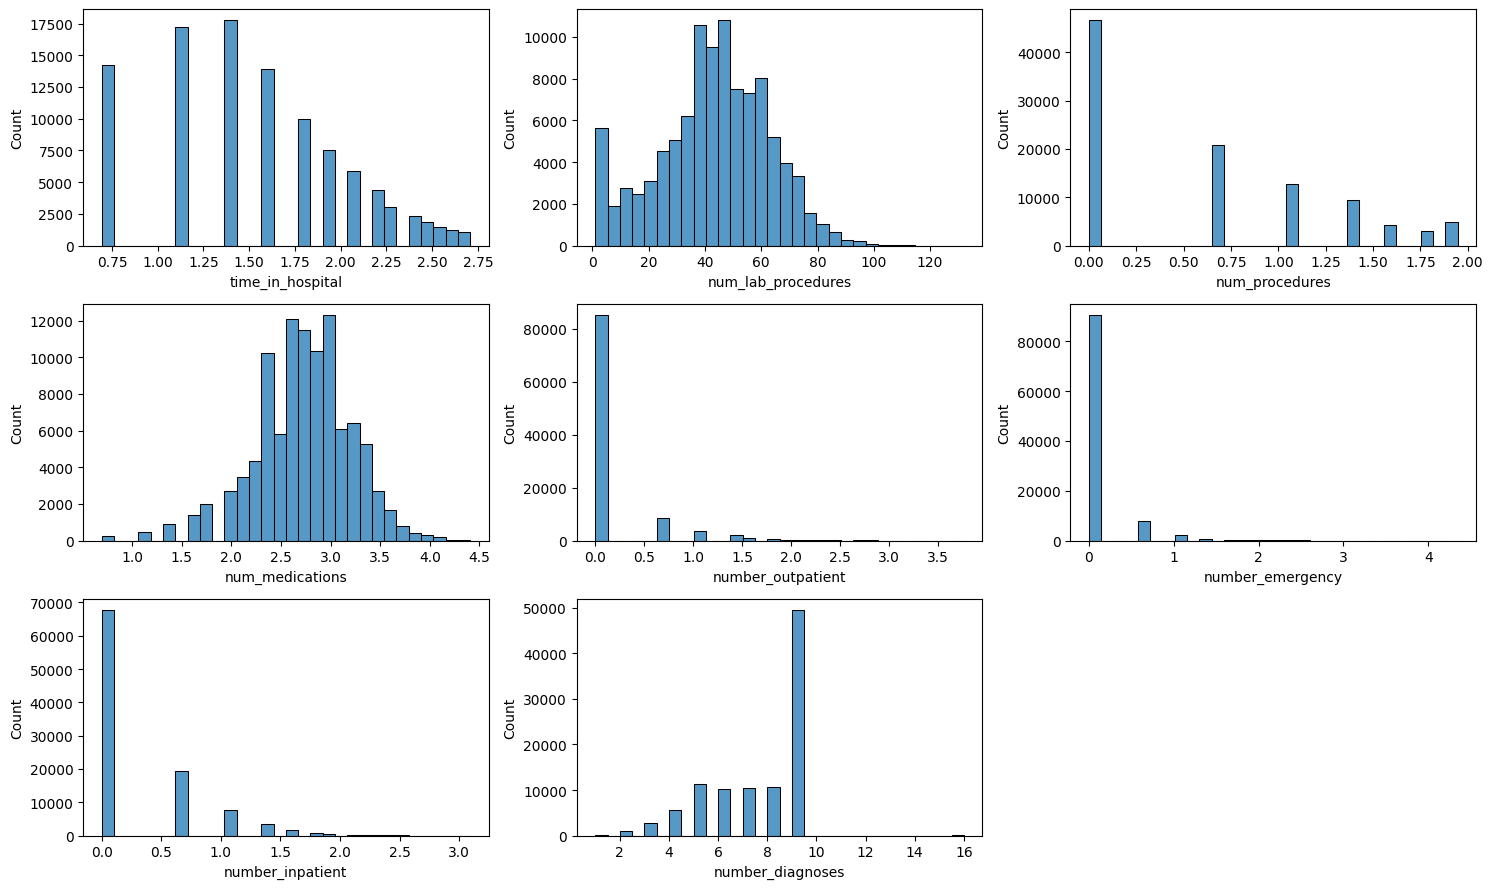

In [44]:
cont_hist_plots(num_df_log)

In [45]:
# Examine the discharge disposition data

discharge_disposition_map = {
    1: "Discharged to home",
    2: "Discharged/transferred to another short term hospital",
    3: "Discharged/transferred to SNF",
    4: "Discharged/transferred to ICF",
    5: "Discharged/transferred to another type of inpatient care institution",
    6: "Discharged/transferred to home with home health service",
    7: "Left AMA",
    8: "Discharged/transferred to home under care of Home IV provider",
    9: "Admitted as an inpatient to this hospital",
    10: "Neonate discharged to another hospital for neonatal aftercare",
    11: "Expired",
    12: "Still patient or expected to return for outpatient services",
    13: "Hospice / home",
    14: "Hospice / medical facility",
    15: "Discharged/transferred within this institution to Medicare approved swing bed",
    16: "Discharged/transferred/referred another institution for outpatient services",
    17: "Discharged/transferred/referred to this institution for outpatient services",
    18: "NULL",
    19: "Expired at home. Medicaid only, hospice.",
    20: "Expired in a medical facility. Medicaid only, hospice.",
    21: "Expired, place unknown. Medicaid only, hospice.",
    22: "Discharged/transferred to another rehab fac including rehab units of a hospital.",
    23: "Discharged/transferred to a long term care hospital.",
    24: "Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare.",
    25: "Not Mapped",
    26: "Unknown/Invalid",
    27: "Discharged/transferred to a federal health care facility.",
    28: "Discharged/transferred/referred to a psychiatric hospital or psychiatric distinct part unit of a hospital",
    29: "Discharged/transferred to a Critical Access Hospital (CAH).",
    30: "Discharged/transferred to another Type of Health Care Institution not Defined Elsewhere"
}

X_discharge = X['discharge_disposition_id'].map(discharge_disposition_map)

X_discharge.value_counts()

discharge_disposition_id
Discharged to home                                                                                           60234
Discharged/transferred to SNF                                                                                13954
Discharged/transferred to home with home health service                                                      12902
NULL                                                                                                          3691
Discharged/transferred to another short term hospital                                                         2128
Discharged/transferred to another rehab fac including rehab units of a hospital.                              1993
Expired                                                                                                       1642
Discharged/transferred to another type of inpatient care institution                                          1184
Not Mapped                                             

# Data Preparation

### Initial Cleaning

In [46]:
from shared_util.dataio import load_csv

df = load_csv('diabetic_data')

df = df.reset_index().rename(columns={'index': 'encounter_id'})


display(df.head())

X = df.drop(columns=['readmitted'])
y = df['readmitted']

y = pd.DataFrame(y)
y.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


,readmitted
0,NO
1,>30
2,NO
3,NO
4,NO


Fix columns not read as strings

In [47]:
# fix diag column types
X['diag_1'] = X['diag_1'].astype('string')
X['diag_2'] = X['diag_2'].astype('string')
X['diag_3'] = X['diag_3'].astype('string')

# fix specialty column type
X['medical_specialty'] = X['medical_specialty'].astype('string')

# fix race
X['race'] = X['race'].astype('string')

# fix age
X['age'] = X['age'].astype('string')

X['change'] = X['change'].astype('string')

Derive Target variable

In [48]:
y['readmitted'] = y['readmitted'].astype('string')

y['target'] = (y['readmitted'] == '<30').astype(int)

In [49]:
# drop weight and payer_code missing and un informative
X_0 = X.drop(columns=['weight', 'payer_code'])

Class balance before cleaning

In [50]:
print(f'Percent Readmitted In under 30 days: {y['target'].mean()*100:.2f}%')

Percent Readmitted In under 30 days: 11.16%


Drop Newborn Rows

In [51]:
# drop the newborn rows
newborn = (X_0['admission_type_id'] == 4) | (X_0['discharge_disposition_id'] == 10)

_pre = len(X_0)


X_1 = X_0.loc[~newborn].reset_index(drop=True)
y   = y.loc[~newborn].reset_index(drop=True)
print(f'dropped: {_pre - len(X_1)}')

dropped: 16


Drop Invalid Gender

In [52]:
# Drop rows with invalid gender
valid_gender = (X_1['gender'] == 'Male') | (X_1['gender'] == 'Female')
_pre = len(X_1)
X_2 = X_1.loc[valid_gender].reset_index(drop=True)
y   = y.loc[valid_gender].reset_index(drop=True)
print(f'dropped: {_pre - len(X_2)}')

dropped: 3


Drop the rows that contain information about a patient Expiring. These rows leak future information not known at prediction time.

In [53]:
# drop rows that show a patient expired

# from mapping info
_c = 'discharge_disposition_id'

expired_ids = [11, 19, 20]


exp_mask = X_2[_c].isin(expired_ids)

_pre = len(X_2)
X_3 = X_2.loc[~exp_mask].reset_index(drop=True)
y   = y.loc[~exp_mask].reset_index(drop=True)
print(f'dropped: {_pre - len(X_3)}')


dropped: 1652


Drop rows for patients who were not discharged (transferred to another inpatient facility)

In [54]:
transferred_ids = [2, 3, 4, 5, 15, 22, 23, 24, 27, 28, 29, 30]
trans_mask = X_3[_c].isin(transferred_ids)
_pre = len(X_3)
X_3 = X_3.loc[~trans_mask].reset_index(drop=True)
y = y.loc[~trans_mask].reset_index(drop=True)
print(f'dropped {_pre - len(X_3)}')

dropped 20740


Export cleaned up data to csv. This becomes the base before being passed into the cleaning pipeline detailed below.

In [55]:
import os
from pathlib import Path

# DATA_DIR = Path('../src/shared_util/data')
# os.makedirs(DATA_DIR, exist_ok=True)
print(f'{len(X_3)} rows after cleaning')
print(f'len y={len(y['target'])}')
X_3_w = pd.concat([X_3, y['target']], axis=1)
#X_3_w.to_csv(DATA_DIR / 'cleaned.csv')

79355 rows after cleaning
len y=79355


Class balance post cleaning

In [56]:
print(f'Percent Readmitted In under 30 days: {y['target'].mean()*100:.2f}%')

Percent Readmitted In under 30 days: 10.02%


# Data Cleaning Pipeline

After initial row wise drops of bad data, the data was exported to csv. This data is the data read in to each cleaning pipeline.

This pipeline runs inside an sklearn (imblearn) pipeline to transform data across train/validate/test splits and cross validation folds without leaking global data beween splits or folds

The below code is illustrative of this process.

## Feature Transformation
Bin, organize, impute missing data, drop some un-needed columns. 

The strategy that follows is based off of the strategy performed by Strack et al. in their study: 

*Impact of HbA1c Measurement on Hospital Readmission Rates:
Analysis of 70,000 Clinical Database Patient Records*

**Start by binning categorical columns**


In [57]:
from IPython.display import Image, display
display(Image('../data/figs/binning.png'))

FileNotFoundError: No such file or directory: '../data/figs/binning.png'

FileNotFoundError: No such file or directory: '../data/figs/binning.png'

<IPython.core.display.Image object>

In [58]:
# Read data in
from shared_util.dataio import load_csv

df = load_csv('cleaned')

X = df.drop(columns=['target'])
y = df['target']

In [59]:
def bin_categories(X):
        import re
        # bin diagnoses into groups 
        _icd_num_re = re.compile(r'^(\d{3})(?:\.\d+)?$')   # e.g., '250.13' -> '250'

        def _parse_icd9(code):
            """
            Returns (prefix, num) where:
            - prefix is 'E', 'V', or '' for numeric codes
            - num is an integer 3-digit number if numeric; else None
            """
            if code is None or (isinstance(code, float) and np.isnan(code)):
                return '', None
            s = str(code).strip()
            if not s:
                return '', None
            first = s[0].upper()
            if first in ('E', 'V'):
                return first, None
            m = _icd_num_re.match(s)
            if m:
                return '', int(m.group(1))
            # Try float -> int of floor integer part
            try:
                return '', int(float(s))
            except Exception:
                return '', None

        def icd9_to_group(code):
            """
            Map a single ICD-9 code to the study's diagnosis group.
            """
            prefix, num = _parse_icd9(code)

            # External causes (E or V) 
            if prefix in ('E', 'V'):
                return 'other'

            if num is None:
                return 'other'

            # Special case: Diabetes 250.xx
            if 250 <= num <= 250:
                return 'diabetes'

            # Primary named groups
            if (390 <= num <= 459) or (num == 785):
                return 'circulatory'
            if (460 <= num <= 519) or (num == 786):
                return 'respiratory'
            if (520 <= num <= 579) or (num == 787):
                return 'digestive'
            if 800 <= num <= 999:
                return 'injury'
            if 710 <= num <= 739:
                return 'musculoskeletal'
            if (580 <= num <= 629) or (num == 788):
                return 'genitourinary'
            if 140 <= num <= 239:
                return 'neoplasms'

            return 'other'
        
        # Admission source -> 3 bins
        def bin_admit_source(id: int) -> str:
            if id == 7:
                return 'emergency'
            if id == 1 or id == 2:
                return 'refer'
            return 'other'
        
        # Medical Specialty of admitting physician -> 6 bins including missing
        def bin_medical_specialty(value: str) -> str:
            if pd.isna(value) or value in ("Missing", "Unknown", "PhysicianNotFound", "OutreachServices", "DCPTEAM"):
                return "missing"
            
            # normalize casing and spacing just in case
            val = str(value).strip().lower()
            
            # Internal Medicine
            if "internal" in val:
                return "internal_medicine"
            
            # Cardiology
            if "cardio" in val:
                return "cardiology"
            
            # Surgery (catch-all for surgical specialties)
            if "surg" in val or "orthopedic" in val or "urology" in val or "gyneco" in val or "neuro" in val or "vascular" in val or "thoracic" in val:
                return "surgery"
            
            # Family / General Practice
            if "family" in val or "general" in val or "gp" in val or "obstetric" in val or "pediatr" in val:
                return "pcp"
            
            # Everything else
            return "other"
        # Discharge Dispostion -> 

        def bin_discharge(id: int) -> str:
            if id in [1, 6, 8, 13]:
                return 'home'
            if id in [2, 3, 4, 5, 15, 22, 23, 24, 27, 28, 29, 30]:
                raise ValueError('Inpatient-fransferred patient detected')
            if id in [16, 17, 12]:
                return 'outpatient_followup'
            if id == 7:
                return 'left_ama'
            if id in [18, 25, 26]:
                return 'unknown'
            return 'unknown'
        
        # bin race -> Hispanic/Asian -> other since they have few values
        def bin_race(race: str) -> str:
            if (pd.isna(race)):
                return "other"
            race = race.strip().lower()
            if race == "caucasian":
                return "caucasian"
            if race == "africanamerican":
                return "african_american"
            return "other"
    

        # bin age -> 3 groups
        def bin_age(age: str) -> str:
            # grabs [0-10], [10-20], [20-30]
            if ('10' in age or '20' in age):
                return 'under_30'
            # grabs (30-40), (40-50), (50-60)
            if ('40' in age or '50' in age):
                return '30-60'
            return 'over_60'
        # bin a1c results
        def bin_a1c(val: str) -> str:
            if pd.isna(val):
                return 'no_test'
            if val in ('>7', '>8'):
                return 'high'
            if val.lower().startswith('norm'):
                return 'normal'
            return 'no_test'
        def bin_glucose(val: str) -> str:
            if pd.isna(val):
                return 'no_test'
            if val in ('>200', '>300'):
                return 'high'
            if val.lower().startswith('norm'):
                return 'normal'
            return 'no_test'
        
        # bin admission type id 
        def bin_admit_type(id: int) -> str:
            if id in [5, 6, 8]: # Not Available, NULL, Not mapped
                return 'na'
            if id in [1,7]: # Emergency, Trauma Center
                return 'emergency'
            if id == 2:
                return 'urgent'
            if id == 3:
                return 'elective'
            return 'other'
        
        # bin number outpatient
        def bin_procedure_cols(num: int) -> str:
            if num == 0:
                return 'none'
            if num == 1:
                return 'one'
            if num in [2,3]:
                return 'few'
            if num < 8:
                return 'several'
            return 'frequent'
        

        _X = X.copy()


        _X['diag1_group'] =_X['diag_1'].apply(icd9_to_group)
        _X['diag2_group'] =_X['diag_2'].apply(icd9_to_group)
        _X['diag3_group'] =_X['diag_3'].apply(icd9_to_group)
        _X['admission_source'] =_X['admission_source_id'].apply(bin_admit_source)
        _X['discharge_loc'] =_X['discharge_disposition_id'].apply(bin_discharge)
        _X['specialty_cat'] =_X['medical_specialty'].apply(bin_medical_specialty)
        _X['race_cat'] =_X['race'].apply(bin_race)
        _X['age_group'] =_X['age'].apply(bin_age)
        _X['a1c_group'] =_X['A1Cresult'].apply(bin_a1c)
        _X['glucose_group'] =_X['max_glu_serum'].apply(bin_glucose)
        _X['admit_type_group'] =_X['admission_type_id'].apply(bin_admit_type)
        _X['v_outpatient_group'] =_X['number_outpatient'].apply(bin_procedure_cols)
        _X['v_emergency_group'] =_X['number_emergency'].apply(bin_procedure_cols)

        return _X

Apply the categorical transformations

In [60]:
X_0 = bin_categories(X)

X_0.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'diag1_group',
       'diag2_group', 'diag3_group', 'admission_source', 'discharge_loc',
       'specialty_cat', 'race_cat', 'age_

Drop previous category columns

In [61]:
X_1 = X_0.drop(
    columns=['diag_1', 
             'diag_2', 
             'diag_3', 
             'admission_source_id',
             'discharge_disposition_id',
             'medical_specialty',
             'race',
             'age',
             'A1Cresult',
             'max_glu_serum',
             'admission_type_id'
             ])

One hot encode the new categories

The first columns are one hot encoded for every model

In [62]:
columns = [ 'diag1_group', 
                    'diag2_group', 
                    'diag3_group', 
                    'admission_source',
                    'discharge_loc',
                    'specialty_cat',
                    'race_cat',
                    'age_group',
                    'gender',
                    'a1c_group',
                    'glucose_group',
                    'admit_type_group',
                ]

For linear models, the continous columns that were rencoded to categorical, are one hot encoded. For Tree models, they are left categorical, but transformed to integer

In [63]:
columns.append('v_outpatient_group')
columns.append('v_emergency_group')

In [64]:
X_2 = pd.get_dummies(X_1, columns=columns, dtype=int)
X_2 = X_2.rename(columns={'gender_Female' : 'gender_female', 'gender_Male' : 'gender_male'})


Drug columns are simplified. Other studies dropped several of them. We handle them doing the following:

1. Encode each drug column as a binary changed or unchanged
2. Summarize row-wise across drug columns to create a new *num_drugs* feature
3. Drop all drug columns, drop all drug flags except for Insulin and Metformin

In [65]:
X_2['diabetesMed_flag'] = (X_2['diabetesMed'].str.lower() == 'yes').astype(int)
X_2['change_flag'] = (X_2['change'].str.lower() == 'ch').astype(int)

drug_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

for col in drug_cols:
    X_2[f'{col}_flag'] = (X_2[col].str.lower() != 'no').astype(int)

# sum across medicine for amount of medicine prescribed
X_2['num_drugs'] = X_2[[f'{c}_flag' for c in drug_cols]].sum(axis=1)

For linear models. A number of interaction terms are created.

Baseline will be the interaction terms that were found statistically signifigant in Strack et al.

That is (by P):
- Discharge disposition × Time in hospital (p < 0.001)
- Medical specialty of admitting physician × Age (p < 0.001)
- Primary diagnosis × Time in hospital (p < 0.001)
- Discharge disposition × Race (p < 0.001)
- Discharge disposition × Medical specialty of admitting physician (p = 0.001)
- Medical Specialty x Time in hospitcal (p = 0.001)

I'll leave out for now:
- Discharge disposition x Primary diagnosis (p = 0.005)
- Primary diagnosis x HbA1c (p = 0.004)

In [66]:
X_3 = X_2.copy()
for col in X_3.filter(like='diag1_group_'):
    X_3[f'i_hosp_time__{col}'] = X_3[col] * X_3['time_in_hospital']
    
# medical specialty of admitting physician x time in hospital
for col in X_3.filter(like='specialty_cat_'):
    X_3[f'i_hosp_time__{col}'] = X_3[col] * X_3['time_in_hospital']

# Discharge Disposition x time in hospital
for col in X_3.filter(regex=r'^discharge_loc_'):
    X_3[f'i_hosp_time__{col}'] = X_3[col] * X_3['time_in_hospital']

In [67]:
def add_dummy_interactions(df, left_cols, right_cols, prefix='i_'):
    out = df.copy()
    L = [c for c in left_cols  if c in out.columns]
    R = [c for c in right_cols if c in out.columns]
    count = 0
    for lc in L:
        for rc in R:
            col_name = f'{prefix}{lc}__{rc}'
            out[col_name] = out[lc] * out[rc]
            count += 1

    

    return out


X_4 = X_3.copy()

# setup column lists
specialty_cols = X_4.filter(regex=r'^specialty_cat_').columns.to_list()
age_cols = X_4.filter(regex=r'^age_group_').columns.to_list()
diag_cols = X_4.filter(regex=r'^diag1_group_').columns.to_list()
race_cols = X_4.filter(regex=r'^race_cat_').columns.to_list()
discharge_cols = X_4.filter(regex=r'^discharge_loc_').columns.to_list()


X_4 = add_dummy_interactions(
    X_4,
    left_cols=specialty_cols,
    right_cols=age_cols
)

# discharge dispo x race
X_4 = add_dummy_interactions(
    X_4,
    left_cols= discharge_cols,
    right_cols=race_cols
)

# discharge x specialty

X_4 = add_dummy_interactions(
    X_4,
    left_cols=discharge_cols,
    right_cols=specialty_cols
)

For Linear models, several continous columns are log transformed.

In [68]:
X_5 = X_4.copy()
LOG_TRANSFORM_COLS = np.array(
    ['num_medications', 'num_procedures', 'time_in_hospital', 'number_inpatient'
     ])
X_5[LOG_TRANSFORM_COLS] = np.log1p(X_5[LOG_TRANSFORM_COLS])

The full cleaning pipeline is wrapped inside of a Model Pipeline that handles everything from reading the data in, running the cleaner, running baselines, validation, testing, hyperparameter searches, and feature importance on a spcified model.

This pipeline exposes important variables and settings to the notebook to allow customization of each run

# Code Reference

**The below code is not meant to be run**

This is for reference only. The code is installed as a pip package and imported at the top of the notebook. 

Model runs are performed under their given title (XGBoost, SGD ect...)

### Model Pipeline

In [69]:
import numpy as np
import pandas as pd
from typing import Dict, List, Any
import time
# High-level helpers for configuring preprocessing and running model baselines.


MODELS = ['rf', 'svc', 'sgd', 'xgb']

class ModelPipeline:
    """
    Represents a pipeline to test a model

    Contains setup in a constructor including reading data in and splitting test,val,train sets

    Contains class methods for the following:
        Perumation Importance of Features + graphing
        Baseline testing SMOTE vs Random Undersampling
        Hyperparameter sweeping with desired parameter distribution
        Validation using best estimator from sweep, with optional f2 score calculation
        Test using held out test data using either base threshold of f2 weighted score

        Printing metrics of each step ROC_AUC, prec, acc, recall, confusion matrics, classification report

        Baseline is tested in 10 fold cross validation
        
        Hyperparam tuning is done using RandomizedSearch with 5 folds

        All data is grouped by patient_nbr to handle duplicate patient encounters
    """

    

    class PreprocessorSettings:
        """
        Holds information about preprocessor settings for this pipeline

        Contains factory() to create a new preprocesser with the set settings as needed
        """
        create_interactions: bool = True
        log_transform_cols: np.ndarray | None
        one_hot_ordinal: bool = True

        def __init__(self, 
                     create_interactions=True, 
                     log_transform_cols=None,
                     one_hot_ordinal=True
                     ) -> None:
            self.create_interactions = create_interactions
            self.log_transform_cols = log_transform_cols
            self.one_hot_ordinal = one_hot_ordinal
            
            
        def factory(self):
            from shared_util.pipelines.cleaning import CleaningPipeline
            return CleaningPipeline(
                create_interactions=self.create_interactions,
                log_transform_cols=self.log_transform_cols
                )


    LOG: bool = False
    METRICS_DB_ID: int = 0
    METRIC_NOTES: str = "None"
    data_path: str = "cleaned"
    X_train: Any = None
    X_validate: Any | None = None
    X_test: Any | None = None
    y_train: Any | None = None
    y_validate: Any | None = None
    y_test: Any | None = None
    preprocessor_settings: PreprocessorSettings
    model:str = ""
    random_state: int = 42
    scaler: Any | None = None
    hyperparam_dist: Dict[str, Any]
    tuned: bool = False
    validated: bool = False
    param_scoring:str='roc_auc'
    use_pca: bool = False
    resample: bool = True
        


        

    def __init__(self,
                 *
                 , 
                 log: bool = False, 
                 metrics_db_id: int = 0, 
                 metrics_notes: str = "None", 
                 data_path: str = "cleaned",
                 plot_y_dist: bool = True,
                 random_state: int = 42,
                 create_interactions: bool = True,
                 log_transform_cols: np.ndarray | None = None,
                 model: str = 'rf',
                 scaler: str | None = None, # standard, power
                 group_by_col='patient_nbr',
                 use_pca: bool = False,
                 one_hot_ordinal: bool = True,
                 resample: bool = True
                 ) -> None:
        """
        Create a new pipeline
        """
        # Persist runtime configuration so we can trace every experiment.
        self.LOG = log
        self.METRIC_NOTES = metrics_notes
        self.data_path = data_path
        self.METRICS_DB_ID = metrics_db_id 
        self.random_state = random_state
        self.group_by_col = group_by_col
        self.use_pca = use_pca
        self.resample = resample
        # Lazily attach a scaler because only some models benefit from it.
        if scaler == 'standard':
            from sklearn.preprocessing import StandardScaler
            self.scaler = StandardScaler()
        if scaler == 'power':
            from sklearn.preprocessing import PowerTransformer
            self.scaler = PowerTransformer(method='yeo-johnson', standardize=True)

        # Load the requested dataset and perform the grouped train/validate/test split.
        from shared_util.dataio import load_csv
        from shared_util.split import group_split
        _df = load_csv(data_path)

        self.X_train, self.X_validate, self.X_test, self.y_train, self.y_validate, self.y_test = group_split(_df)


        if plot_y_dist:
            # Quick sanity check: make sure the target distribution is stable across splits.
            from shared_util.metrics.plotting import check_y_dist
            check_y_dist(
                self.y_train,
                self.y_validate,
                self.y_test
            )

        # Freeze preprocessing options inside a helper so we can rebuild identical cleaners on demand.
        self.preprocessor_settings = self.PreprocessorSettings(
            create_interactions=create_interactions,
            log_transform_cols=log_transform_cols,
            one_hot_ordinal=one_hot_ordinal
        )

        
        self.model = model

    def permute_importance(self, print_num=15, plot=True,show_duration_info:bool = True,):
        from sklearn.inspection import permutation_importance
        t0 = time.perf_counter()

        def plot_feature_importance(df, col1, col2, size, title):
            import matplotlib.pyplot as plt
            plt.figure(figsize=(10,6))
            plt.barh(df[col1][:size][::-1], df[col2][:size][::-1])
            plt.title(title)
            plt.xlabel("Importance")
            plt.tight_layout()
            plt.show()

        def _transform_through_inference_steps(pipe, X, model_step='model'):
            """
            Apply only transform-capable steps in a fitted imblearn Pipeline.
            Skip any sampler (fit_resample-only). Stop before the final estimator.
            """
            Xt = X
            for name, step in pipe.steps:
                if name == model_step:
                    break
                # Skip samplers (no transform)
                if hasattr(step, "fit_resample"):
                    continue
                if hasattr(step, "transform"):
                    Xt = step.transform(Xt)
                else:
                    # Non-sampler but also no transform? treat as passthrough
                    pass
            return Xt
        

        def cv_permutation_importance(
            pipe_factory, X, y, cv, groups=None,
            scoring="roc_auc", n_repeats=10, n_jobs=-1, random_state=42,
            model_step='model', prep_step='preprocessor'
        ):
            # Compute permutation importance fold by fold so samplers respect the group structure.
            perm_means = []
            feat_names = None

            for tr_idx, va_idx in cv.split(X, y, groups):
                X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
                X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

                # Rebuild a fresh pipeline each iteration to avoid cross-fold leakage.
                pipe = pipe_factory(self.model)
                pipe.fit(X_tr, y_tr)

                # Transform validation through inference-capable steps
                Xt_va = _transform_through_inference_steps(pipe, X_va, model_step=model_step)

                # Get names from the preprocessor if available; otherwise fallback
                preproc = pipe.named_steps.get(prep_step)
                if hasattr(preproc, "get_feature_names_out"):
                    feat_names_fold = np.asarray(preproc.get_feature_names_out(), dtype=object)
                else:
                    feat_names_fold = np.array([f"x{i}" for i in range(Xt_va.shape[1])], dtype=object)

                if feat_names is None:
                    feat_names = feat_names_fold
                else:
                    if len(feat_names) != len(feat_names_fold):
                        raise RuntimeError("Transformed feature count changed across folds; pipeline not schema-stable.")

                model = pipe.named_steps[model_step]

                # Measure how sensitive the fitted model is to each feature on this fold.
                r = permutation_importance(
                    model, Xt_va, y_va,
                    scoring=scoring, n_repeats=n_repeats,
                    n_jobs=n_jobs, random_state=random_state
                )
                perm_means.append(r.importances_mean) #type: ignore

            arr = np.vstack(perm_means)
            df = pd.DataFrame({
                "feature": feat_names,
                "importance_mean": arr.mean(axis=0),
                "importance_std": arr.std(axis=0)
            }).sort_values("importance_mean", ascending=False)
            return df
        
        # Aggregate the per-fold importances into a single ranked table.
        _perm_imp = cv_permutation_importance(
            pipe_factory=self._pipe_factory,
            X=self.X_train,
            y=self.y_train,
            cv=self._make_group_cv(),
            groups=self.X_train[self.group_by_col]
        )

        from IPython.display import display

        display(_perm_imp.head(print_num))

        if plot:
            plot_feature_importance(
                _perm_imp, 
                'feature', 
                'importance_mean', 
                print_num, 
                f'Permutation Importance ({self.model})')
            
        if show_duration_info:
            self._print_dur(t0)

    def test(self, 
         use_f2_threshold=True,
         use_cost_threshold=False,
         R: float = 16300.0,
         e: float = 0.50,
         c_m_list=(500.0, 1000.0, 1500.0),
         prefer_c_m: float | None = 1000.0,  # choose None to maximize average
         show_plot=True,
         show_duration_info: bool = False,
         use_local_model=False,
         **kwargs):
        """
        New: use_cost_threshold selects threshold maximizing $ savings on the validate set.
        - Overlays: PR curve with break-even PPV lines, and savings vs threshold per c_m.
        - If both use_f2_threshold and use_cost_threshold are True, cost wins. Because money.
        """
        if (not self.validated or not self.tuned) and not use_local_model:
            raise EnvironmentError("Must validate before test")

        import time
        import numpy as np
        from shared_util.metrics.scoring import (
            get_scores, best_threshold_by_fbeta,
            cost_curves_from_scores, best_threshold_by_cost
        )
        from shared_util.metrics.plotting import plot_pr_with_break_even, plot_savings_vs_threshold
        from shared_util.metrics.printing import print_metrics

        # Fit or load model
        if use_local_model:
            _model = self._pipe_factory(
                model=self.model,
                random_state=self.random_state,
                sampler='under',
                **kwargs
            )
            _model.fit(self.X_train, self.y_train)
        else:
            _model = self.randomized_search.best_estimator_

        t0 = time.perf_counter()

        # 1) Scores on validate for threshold selection
        _val_scores = get_scores(_model, self.X_validate)

        threshold_notes = 'baseline'
        chosen_thresh = None
        est_pp_savings = 0.0

        if use_cost_threshold:
            # Build cost curves on validate
            curves = cost_curves_from_scores(
                y_true=self.y_validate,
                y_scores=_val_scores,
                R=R, e=e, c_m_list=c_m_list
            )
            choice = best_threshold_by_cost(curves, prefer_c_m=prefer_c_m)

            chosen_thresh = choice["threshold"]
            threshold_notes = f'cost_opt_R={int(R)}_e={e:.2f}_c={("avg" if choice["chosen_c_m"] is None else int(choice["chosen_c_m"]))}'

            if choice["chosen_c_m"] is None:
                # maximizing average across c_m_list
                est_pp_savings = float(np.mean(list(choice["savings_at_c"].values())))
            else:
                # using a specific c_m
                est_pp_savings = float(choice["savings_at_c"][choice["chosen_c_m"]])
            
            # Optional overlays
            if show_plot:
                title = f"PR with break-even PPV lines (R=${int(R)}, e={e:.2f})"
                plot_pr_with_break_even(curves, R=R, e=e, c_m_list=c_m_list, title=title)

                title2 = f"Savings vs Threshold on validate (per 1000 patients)"
                plot_savings_vs_threshold(curves, c_m_list=c_m_list, per_1000=True, title=title2)


            print(
                f"[COST] Chosen threshold: {chosen_thresh:.4f} | "
                f"PPV={choice['precision']:.3f}  Recall={choice['recall']:.3f}  "
                f"FlagRate={choice['flag_rate']:.3f}  "
                f"Savings@{('avg' if choice['chosen_c_m'] is None else '$'+str(int(choice['chosen_c_m'])))}="
                f"{est_pp_savings:.2f} per patient"
            )

        elif use_f2_threshold:
            # legacy F2 optimization path
            info = best_threshold_by_fbeta(self.y_validate, _val_scores, beta=2.0)
            chosen_thresh = info['threshold']
            threshold_notes = 'f2_weighted'
            if show_plot and 'curve' in info:
                from shared_util.metrics.scoring import plot_scoring
                plot_scoring(info['curve'])
            print(
                f"[F2] Best threshold: {chosen_thresh:.4f} | "
                f"Precision={info['precision']:.3f}  Recall={info['recall']:.3f}  F2={info['fbeta']:.3f}"
            )

        # 2) Apply chosen threshold to test (or native predict if neither path)
        _test_scores = get_scores(_model, self.X_test)
        if chosen_thresh is not None:
            y_pred = (_test_scores >= chosen_thresh).astype(int)
        else:
            y_pred = _model.predict(self.X_test)  # type: ignore

        # 3) Print/log test metrics
        from shared_util.metrics.printing import print_metrics
        print_metrics(
            y_true=self.y_test,
            y_pred=y_pred,
            y_proba=_test_scores,
            run_id=self.METRICS_DB_ID,
            metrics_notes=self.METRIC_NOTES,
            data='test',
            threshold_notes=threshold_notes,
            model=self.model,
            hyperparam_notes='tuned_best_roc_auc',
            pipeline_notes='under_sample',
            est_pp_savings=est_pp_savings,
            log=self.LOG
        )

        if show_duration_info:
            self._print_dur(t0)


    def validate(self, 
                 show_duration_info:bool = False,
                 use_local_model=False,
                 **kwargs
                 ):
        if not self.tuned and not use_local_model:
            raise EnvironmentError("Must run hyperparam search first")
            
        from shared_util.metrics.scoring import get_scores
        t0 = time.perf_counter()
        
        if use_local_model:
            _model = self._pipe_factory(
                model=self.model,
                random_state=self.random_state,
                sampler='under',
                **kwargs
                )
            _model.fit(self.X_train, self.y_train)
        else:
            _model = self.randomized_search.best_estimator_


        # Pull calibrated probabilities and convert them to hard labels via the tuned estimator.
        y_proba = get_scores(_model, self.X_validate)
        y_pred = _model.predict(self.X_validate) #type: ignore

        print(f"Held out validation metrics: {(self.model)}")

        from shared_util.metrics.printing import print_metrics

        print_metrics(
            y_true=self.y_validate,
            y_pred=y_pred,
            y_proba=y_proba,
            metrics_notes=self.METRIC_NOTES,
            run_id=self.METRICS_DB_ID,
            model=self.model,
            data='validate',
            hyperparam_notes=f'tuned best {(self.param_scoring)}',
            pipeline_notes='under_sample',
            log=self.LOG,
            
        )

        self.validated = True

        if show_duration_info:
            self._print_dur(t0)

    def run_hyperparam_search(self,
                 hyperparam_dist = {},
                 param_scoring='roc_auc',
                 n_iter = 30,
                 n_jobs = -1,
                 refit=True,
                 show_duration_info=True,
                 verbose=1
                              ):
        t0 = time.perf_counter()
        from sklearn.model_selection import RandomizedSearchCV

        # Build a full pipeline so tuning evaluates preprocessing, sampling, and the estimator together.
        rs = RandomizedSearchCV(
            estimator=self._pipe_factory(self.model, random_state=self.random_state),
            param_distributions=hyperparam_dist,
            n_iter=n_iter,
            refit=refit,
            random_state=self.random_state,
            n_jobs=n_jobs,
            scoring=param_scoring,
            cv=self._make_group_cv(),
            verbose=verbose
        )

        # Group-aware fit ensures we never leak a patient's encounters across folds.
        rs.fit(
            self.X_train,
            self.y_train,
            groups=self.X_train[self.group_by_col]
        )


        print("Best ROC_AUC (cv):", rs.best_score_)
        print("Best params:", rs.best_params_)

        # Summarize top results
        res_df = pd.DataFrame(rs.cv_results_).sort_values('rank_test_score').reset_index(drop=True)
        res_df[['rank_test_score','mean_test_score','std_test_score','params']].head(10)

        # Persist tuning artifacts so downstream steps (validate/test) can reuse the best estimator.
        self.randomized_search = rs
        self.rs_df = res_df
        self.param_scoring = param_scoring
        self.tuned = True

        if self.LOG:
            from shared_util.log import log_hyperparameters
            log_hyperparameters(
                run_id=self.METRICS_DB_ID,
                model=self.model,
                hyperparam_text=str(rs.best_params_)
            )

        
        if show_duration_info:
            self._print_dur(t0)


    def run_baseline(self,
                 run_undersampler: bool = True,
                 run_smote: bool = True,
                 show_duration_info:bool = True,
                 ):
        
        t0 = time.perf_counter()

        

        def _run_model(pipeline_notes, sampler):
            # Local helper so each sampler shares the same preprocessing + logging logic.
            from shared_util.baseline import get_baseline_score

            # Build a single estimator that each sampling strategy will pair with.
            _pipe = self._pipe_factory(self.model, self.random_state, sampler=sampler)
        
            _roc_auc = get_baseline_score(
                pipe=_pipe,
                X_train=self.X_train,
                y_train=self.y_train,
                cv=self._make_group_cv()
            )

            if self.LOG:
                from shared_util.log import log_metric
                log_metric(
                    run_id=self.METRICS_DB_ID,
                    model=self.model,
                    threshold_notes='base',
                    data='train',
                    pipeline_notes=pipeline_notes,
                    notes=self.METRIC_NOTES,
                    roc_auc=_roc_auc
                )

        if run_smote:
            from imblearn.over_sampling import SMOTE
            print('--------SMOTE Baseline--------')
            # Compare against an oversampling strategy that synthesizes minority examples.
            _run_model('smote', 'smote')        

        if run_undersampler:
            from imblearn.under_sampling import RandomUnderSampler
            print('-----Undersample Baseline-----')
            # Also measure performance when we downsample the majority class.
            _run_model('under_sample', 'under')
    

        if show_duration_info:
            self._print_dur(t0)
        
    def _make_group_cv(self, n_splits=5):
        from sklearn.model_selection import StratifiedGroupKFold
        return StratifiedGroupKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=self.random_state
        )
    
    def _print_dur(self, t0 = 0.0):

        def _fmt_time(dur):
            total_seconds_int = int(dur)

            minutes, seconds = divmod(total_seconds_int, 60)
            hours, minutes = divmod(minutes, 60)

            fractional_seconds = dur - total_seconds_int
            seconds += fractional_seconds

            return f'{hours} hrs, {minutes} mins, {seconds:.1f} secs'

        

        print(f'Duration: {_fmt_time(time.perf_counter() - t0)}')
    
    def _model_factory(self, model:str, **kwargs):
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.linear_model import SGDClassifier
        from sklearn.svm import SVC
        from xgboost import XGBClassifier

        match model:
            case 'rf':
                return RandomForestClassifier(**kwargs)
            case 'sgd':
                return SGDClassifier(**kwargs)
            case 'svc':
                return SVC(kernel='rbf', **kwargs)
            case 'xgb':
                return XGBClassifier(objective='binary:logistic',
                                     tree_method='hist', 
                                     eval_metric='aucpr',
                                     device='cuda',
                                     **kwargs)
            case _:
                raise ValueError(f"Unknown model '{model}'")
            
    def _pipe_factory(self, model:str, random_state=42, sampler='under', **kwargs):
        from imblearn.pipeline import Pipeline
        from typing import Tuple

        _pre = self.preprocessor_settings.factory()
        steps:List[Tuple[str, Any]] = [("preprocessor", _pre)]

        if self.resample:
            # Choose the sampling strategy while keeping the interface consistent.
            if sampler == 'under':
                from imblearn.under_sampling import RandomUnderSampler
                _sampler = RandomUnderSampler(random_state=random_state)

            elif sampler == 'smote':
                from imblearn.over_sampling import SMOTE
                _sampler = SMOTE(random_state=random_state)

            steps.append(("sampler", _sampler))
        

        if self.scaler is not None:
            steps.append(("scaler", self.scaler))

        if self.use_pca:
            from sklearn.decomposition import PCA
            pca = PCA(n_components=0.95)
            steps.append(('PCA', pca))

        _model = self._model_factory(model=model, random_state=random_state, **kwargs)

        steps.append(("model", _model))

        return Pipeline(steps=steps)


### Cleaning Pipeline

In [70]:
import numpy as np
import pandas as pd
import re
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array
from typing import List

class CleaningPipeline(BaseEstimator, TransformerMixin):

    X: pd.DataFrame


    def __init__(self, 
                 create_interactions=True, 
                 log_transform_cols:None | np.ndarray=None,
                 one_hot_ordinal:bool = True
                 ) -> None:
        self.create_interactions = create_interactions
        self.log_transform_cols = log_transform_cols
        self.one_hot_ordinal = one_hot_ordinal


    def run_pipe(self):
        self.bin_categories()
        self.drop_previous_category_cols()
        self.one_hot_cats()
        self.handle_drug_cols()

        if self.create_interactions:
            self.create_numerical_interactions()
            self.add_dummy_interactions()

        if self.log_transform_cols is not None and len(self.log_transform_cols) > 0:
            self.log_transform_continous_features()

        if not self.one_hot_ordinal:
            # transform binned ordinal categories into numeric encodings for tree models
            mapping = {
                'none': 0,
                'one': 1,
                'few': 3,
                'several': 6,
                'frequent': 10
            }

            ordinal_cols = ['v_outpatient_group', 'v_emergency_group']
            
            for col in ordinal_cols:
                num_col = f"{col}_num"
                self.X[num_col] = self.X[col].map(mapping).astype('Int64')

            self.X.drop(columns=ordinal_cols, inplace=True)
            


    def fit(self, X, y=None):
        X = self._ensure_dataframe(X)
        self.feature_names_in_ = np.array(X.columns, dtype=object)
        self.n_features_in_ = X.shape[1]
        self.X = X.copy()

        self.run_pipe()

   
        self._ref_dummies_ = self._choose_ref_dummies(self.X)

       
        self.X = self.X.drop(columns=list(self._ref_dummies_.values()), errors="ignore")

       
        self._safe_drop_non_features()

        # Freeze final schema
        self.feature_names_out_ = np.array(self.X.columns, dtype=object)
        self._out_dtypes_ = self.X.dtypes.to_dict()

        return self
    

    def log_transform_continous_features(self):
        self.X[self.log_transform_cols] = np.log1p(self.X[self.log_transform_cols])

    def transform(self, X):
        from sklearn.utils.validation import check_is_fitted
        check_is_fitted(self, ["feature_names_out_", "_out_dtypes_"])
        Xw = self._ensure_dataframe(X, like=self.feature_names_in_).copy()
        X_prev = getattr(self, "X", None)
        try:
            self.X = Xw

            self.run_pipe()

            # Drop the same refs chosen at fit, if they exist in this X
            if hasattr(self, "_ref_dummies_"):
                self.X = self.X.drop(columns=list(self._ref_dummies_.values()), errors="ignore")

            self._safe_drop_non_features()

            Xw = self.X
        finally:
            if X_prev is not None:
                self.X = X_prev

        # align to training schema
        for col in self.feature_names_out_:
            if col not in Xw.columns:
                Xw[col] = 0
        Xw = Xw.loc[:, self.feature_names_out_]

        for c, dt in self._out_dtypes_.items():
            if c in Xw.columns:
                try: Xw[c] = Xw[c].astype(dt, copy=False)
                except: pass

        return Xw
    
    def _safe_drop_non_features(self):
        # Raw strings we never want in model space
        base_drop = ['diabetesMed', 'change', 'patient_nbr', 'encounter_id']

        drug_cols = [
            'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
            'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
            'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
            'glipizide-metformin', 'glimepiride-pioglitazone',
            'metformin-rosiglitazone', 'metformin-pioglitazone'
        ]

        # Drop drug strings and all flags EXCEPT keep metformin_flag and insulin_flag
        drop_flags = [f"{c}_flag" for c in drug_cols if c not in ('metformin', 'insulin')]

        to_drop = [c for c in (base_drop + drug_cols + drop_flags) if c in self.X.columns]
        if to_drop:
            self.X = self.X.drop(columns=to_drop, errors="ignore")


    def get_feature_names_out(self, input_features=None):
        from sklearn.utils.validation import check_is_fitted
        check_is_fitted(self, "feature_names_out_")
        return self.feature_names_out_

    
    def _ensure_dataframe(self, X, like: np.ndarray | None = None) -> pd.DataFrame:
        """
        Accept pandas or numpy; if numpy, wrap in a DataFrame with either the
        original training column names (when available) or generic names.
        """
        if isinstance(X, pd.DataFrame):
            return X
        X_arr = check_array(X, accept_sparse=False, dtype=None, force_all_finite="allow-nan")
        if like is not None:
            cols = list(like)
        else:
            cols = [f"x{i}" for i in range(X_arr.shape[1])]
        return pd.DataFrame(X_arr, columns=cols)

    def add_dummy_interactions(self):
        def add_dummy_interactions(df, left_cols, right_cols, prefix='i_'):
            out = df.copy()
            L = [c for c in left_cols  if c in out.columns]
            R = [c for c in right_cols if c in out.columns]
            count = 0
            for lc in L:
                for rc in R:
                    col_name = f'{prefix}{lc}__{rc}'
                    out[col_name] = out[lc] * out[rc]
                    count += 1

            

            return out
        
        # setup column lists
        specialty_cols = self.X.filter(regex=r'^specialty_cat_').columns.to_list()
        age_cols = self.X.filter(regex=r'^age_group_').columns.to_list()
        diag_cols = self.X.filter(regex=r'^diag1_group_').columns.to_list()
        race_cols = self.X.filter(regex=r'^race_cat_').columns.to_list()
        discharge_cols = self.X.filter(regex=r'^discharge_loc_').columns.to_list()


        self.X = add_dummy_interactions(
            self.X,
            left_cols=specialty_cols,
            right_cols=age_cols
        )

        # discharge dispo x race
        self.X = add_dummy_interactions(
            self.X,
            left_cols= discharge_cols,
            right_cols=race_cols
        )

        # discharge x specialty

        self.X = add_dummy_interactions(
            self.X,
            left_cols=discharge_cols,
            right_cols=specialty_cols
        )

    def create_numerical_interactions(self):
        for col in self.X.filter(like='diag1_group_'):
            self.X[f'i_hosp_time__{col}'] = self.X[col] * self.X['time_in_hospital']
            
        # medical specialty of admitting physician x time in hospital
        for col in self.X.filter(like='specialty_cat_'):
            self.X[f'i_hosp_time__{col}'] = self.X[col] * self.X['time_in_hospital']
        
        # Discharge Disposition x time in hospital
        for col in self.X.filter(regex=r'^discharge_loc_'):
            self.X[f'i_hosp_time__{col}'] = self.X[col] * self.X['time_in_hospital']


    def _choose_ref_dummies(self, X: pd.DataFrame) -> dict[str, str]:
        # Map each dummy family to a regex
        families = {
            'diag1_group_':       r'^diag1_group_',
            'diag2_group_':       r'^diag2_group_',
            'diag3_group_':       r'^diag3_group_',
            'admission_source_':  r'^admission_source_',
            'discharge_loc_':     r'^discharge_loc_',
            'specialty_cat_':     r'^specialty_cat_',
            'race_cat_':          r'^race_cat_',
            'age_group_':         r'^age_group_',
            'gender_':            r'^gender_',
            'a1c_group_':         r'^a1c_group_',
            'glucose_group_':     r'^glucose_group_',
            'admit_type_group_':  r'^admit_type_group_',
        }

        if self.one_hot_ordinal:
            families['v_outpatient_group'] = r'^v_outpatient_group'
            families['v_emergency_group'] = r'^v_emergency_group'

        refs = {}
        for fam, pat in families.items():
            cols = X.filter(regex=pat).columns
            if len(cols) >= 2:
                # Choose the most frequent level as reference (sum of one-hot = count)
                counts = X[cols].sum(axis=0)
                ref_col = counts.idxmax()
                refs[fam] = ref_col
        return refs

    def handle_drug_cols(self):
        # swap to binary flags
        self.X['diabetesMed_flag'] = (self.X['diabetesMed'].str.lower() == 'yes').astype(int)
        self.X['change_flag'] = (self.X['change'].str.lower() == 'ch').astype(int)

        drug_cols = [
            'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
            'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
            'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
            'glipizide-metformin', 'glimepiride-pioglitazone',
            'metformin-rosiglitazone', 'metformin-pioglitazone'
        ]

        for col in drug_cols:
            self.X[f'{col}_flag'] = (self.X[col].str.lower() != 'no').astype(int)

        # sum across medicine for amount of medicine prescribed
        self.X['num_drugs'] = self.X[[f'{c}_flag' for c in drug_cols]].sum(axis=1)

    def one_hot_cats(self):
        columns = [ 'diag1_group', 
                    'diag2_group', 
                    'diag3_group', 
                    'admission_source',
                    'discharge_loc',
                    'specialty_cat',
                    'race_cat',
                    'age_group',
                    'gender',
                    'a1c_group',
                    'glucose_group',
                    'admit_type_group',
                ]
        
        if self.one_hot_ordinal:
            columns.append('v_outpatient_group')
            columns.append('v_emergency_group')


        

        # one hot categorical columns
        self.X = pd.get_dummies(self.X, columns=columns, dtype=int)
        
        self.X = self.X.rename(columns={'gender_Female' : 'gender_female', 'gender_Male' : 'gender_male'})

    def drop_previous_category_cols(self):
        columns=['diag_1', 
                'diag_2', 
                'diag_3', 
                'admission_source_id',
                'discharge_disposition_id',
                'medical_specialty',
                'race',
                'age',
                'A1Cresult',
                'max_glu_serum',
                'admission_type_id',
                'number_outpatient',
                'number_emergency'
                ]
        

        self.X = self.X.drop(columns=columns)

    def bin_categories(self):
        # bin diagnoses into groups 
        _icd_num_re = re.compile(r'^(\d{3})(?:\.\d+)?$')   # e.g., '250.13' -> '250'

        def _parse_icd9(code):
            """
            Returns (prefix, num) where:
            - prefix is 'E', 'V', or '' for numeric codes
            - num is an integer 3-digit number if numeric; else None
            """
            if code is None or (isinstance(code, float) and np.isnan(code)):
                return '', None
            s = str(code).strip()
            if not s:
                return '', None
            first = s[0].upper()
            if first in ('E', 'V'):
                return first, None
            m = _icd_num_re.match(s)
            if m:
                return '', int(m.group(1))
            # Try float -> int of floor integer part
            try:
                return '', int(float(s))
            except Exception:
                return '', None

        def icd9_to_group(code):
            """
            Map a single ICD-9 code to the study's diagnosis group.
            """
            prefix, num = _parse_icd9(code)

            # External causes (E or V) 
            if prefix in ('E', 'V'):
                return 'other'

            if num is None:
                return 'other'

            # Special case: Diabetes 250.xx
            if 250 <= num <= 250:
                return 'diabetes'

            # Primary named groups
            if (390 <= num <= 459) or (num == 785):
                return 'circulatory'
            if (460 <= num <= 519) or (num == 786):
                return 'respiratory'
            if (520 <= num <= 579) or (num == 787):
                return 'digestive'
            if 800 <= num <= 999:
                return 'injury'
            if 710 <= num <= 739:
                return 'musculoskeletal'
            if (580 <= num <= 629) or (num == 788):
                return 'genitourinary'
            if 140 <= num <= 239:
                return 'neoplasms'

            return 'other'
        
        # Admission source -> 3 bins
        def bin_admit_source(id: int) -> str:
            if id == 7:
                return 'emergency'
            if id == 1 or id == 2:
                return 'refer'
            return 'other'
        
        # Medical Specialty of admitting physician -> 6 bins including missing
        def bin_medical_specialty(value: str) -> str:
            if pd.isna(value) or value in ("Missing", "Unknown", "PhysicianNotFound", "OutreachServices", "DCPTEAM"):
                return "missing"
            
            # normalize casing and spacing just in case
            val = str(value).strip().lower()
            
            # Internal Medicine
            if "internal" in val:
                return "internal_medicine"
            
            # Cardiology
            if "cardio" in val:
                return "cardiology"
            
            # Surgery (catch-all for surgical specialties)
            if "surg" in val or "orthopedic" in val or "urology" in val or "gyneco" in val or "neuro" in val or "vascular" in val or "thoracic" in val:
                return "surgery"
            
            # Family / General Practice
            if "family" in val or "general" in val or "gp" in val or "obstetric" in val or "pediatr" in val:
                return "pcp"
            
            # Everything else
            return "other"
        # Discharge Dispostion -> 

        def bin_discharge(id: int) -> str:
            if id in [1, 6, 8, 13]:
                return 'home'
            if id in [2, 3, 4, 5, 15, 22, 23, 24, 27, 28, 29, 30]:
                raise ValueError('Inpatient-fransferred patient detected')
            if id in [16, 17, 12]:
                return 'outpatient_followup'
            if id == 7:
                return 'left_ama'
            if id in [18, 25, 26]:
                return 'unknown'
            return 'unknown'
        
        # bin race -> Hispanic/Asian -> other since they have few values
        def bin_race(race: str) -> str:
            if (pd.isna(race)):
                return "other"
            race = race.strip().lower()
            if race == "caucasian":
                return "caucasian"
            if race == "africanamerican":
                return "african_american"
            return "other"
    

        # bin age -> 3 groups
        def bin_age(age: str) -> str:
            # grabs [0-10], [10-20], [20-30]
            if ('10' in age or '20' in age):
                return 'under_30'
            # grabs (30-40), (40-50), (50-60)
            if ('40' in age or '50' in age):
                return '30-60'
            return 'over_60'
        # bin a1c results
        def bin_a1c(val: str) -> str:
            if pd.isna(val):
                return 'no_test'
            if val in ('>7', '>8'):
                return 'high'
            if val.lower().startswith('norm'):
                return 'normal'
            return 'no_test'
        def bin_glucose(val: str) -> str:
            if pd.isna(val):
                return 'no_test'
            if val in ('>200', '>300'):
                return 'high'
            if val.lower().startswith('norm'):
                return 'normal'
            return 'no_test'
        
        # bin admission type id 
        def bin_admit_type(id: int) -> str:
            if id in [5, 6, 8]: # Not Available, NULL, Not mapped
                return 'na'
            if id in [1,7]: # Emergency, Trauma Center
                return 'emergency'
            if id == 2:
                return 'urgent'
            if id == 3:
                return 'elective'
            return 'other'
        
        # bin number outpatient
        def bin_procedure_cols(num: int) -> str:
            if num == 0:
                return 'none'
            if num == 1:
                return 'one'
            if num in [2,3]:
                return 'few'
            if num < 8:
                return 'several'
            return 'frequent'
        


        self.X['diag1_group'] = self.X['diag_1'].apply(icd9_to_group)
        self.X['diag2_group'] = self.X['diag_2'].apply(icd9_to_group)
        self.X['diag3_group'] = self.X['diag_3'].apply(icd9_to_group)
        self.X['admission_source'] = self.X['admission_source_id'].apply(bin_admit_source)
        self.X['discharge_loc'] = self.X['discharge_disposition_id'].apply(bin_discharge)
        self.X['specialty_cat'] = self.X['medical_specialty'].apply(bin_medical_specialty)
        self.X['race_cat'] = self.X['race'].apply(bin_race)
        self.X['age_group'] = self.X['age'].apply(bin_age)
        self.X['a1c_group'] = self.X['A1Cresult'].apply(bin_a1c)
        self.X['glucose_group'] = self.X['max_glu_serum'].apply(bin_glucose)
        self.X['admit_type_group'] = self.X['admission_type_id'].apply(bin_admit_type)
        self.X['v_outpatient_group'] = self.X['number_outpatient'].apply(bin_procedure_cols)
        self.X['v_emergency_group'] = self.X['number_emergency'].apply(bin_procedure_cols)
        #self.X['v_inpatient_group'] = self.X['number_inpatient'].apply(bin_procedure_cols)
    

### Scoring

In [71]:
import numpy as np
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from typing import Tuple
from sklearn.metrics import make_scorer, fbeta_score

def cost_curves_from_scores(
    y_true, y_scores, 
    R=16300.0, e=0.50, c_m_list=(500.0, 1000.0, 1500.0)
):
    """
    Returns PR arrays, thresholds, prevalence, flag_rate, and per-patient savings 
    curves for each c_m in c_m_list.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    precision, recall = precision[:-1], recall[:-1]  # align with thresholds
    p = float(np.mean(y_true))

    # flag_rate = P(flag) = (p * recall) / precision
    with np.errstate(divide='ignore', invalid='ignore'):
        flag_rate = np.where(precision > 0, (p * recall) / precision, 0.0)

    savings = {}
    for c_m in c_m_list:
        per_patient = flag_rate * (precision * e * R - c_m)
        savings[c_m] = per_patient

    return {
        "precision": precision,
        "recall": recall,
        "thresholds": thresholds,
        "prevalence": p,
        "flag_rate": flag_rate,
        "savings": savings,   # dict: c_m -> array same length as thresholds
    }

def best_threshold_by_cost(curves, prefer_c_m=None):
    """
    Pick the threshold that maximizes per-patient savings.
    If prefer_c_m is provided, optimize for that single cost.
    Otherwise, pick the argmax over the average savings across c_m_list.
    """
    c_ms = sorted(curves["savings"].keys())
    mat = np.column_stack([curves["savings"][c] for c in c_ms])  # T x C

    if prefer_c_m is None:
        # hedge: maximize mean savings across the cost scenarios
        agg = np.nanmean(mat, axis=1)
        j = int(np.nanargmax(agg))
        chosen_c_m = None
    else:
        # pick threshold optimal for the chosen cost
        idx = c_ms.index(prefer_c_m)
        j = int(np.nanargmax(mat[:, idx]))
        chosen_c_m = prefer_c_m

    return {
        "idx": j,
        "threshold": float(curves["thresholds"][j]),
        "precision": float(curves["precision"][j]),
        "recall": float(curves["recall"][j]),
        "flag_rate": float(curves["flag_rate"][j]),
        "savings_at_c": {c: float(curves["savings"][c][j]) for c in c_ms},
        "chosen_c_m": chosen_c_m,
        "c_m_list": c_ms,
    }

def cost_savings_by_threshold(y_true, y_scores, R=16300, c_m=1000, e=0.50):
    # PR curve returns precision and recall for descending thresholds
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    # Align lengths: thresholds has len-1 vs precision/recall
    precision, recall = precision[:-1], recall[:-1]
    thresholds = thresholds

    y_true = np.asarray(y_true)
    p = y_true.mean()

    # We need FPR or flag_rate. We can recover flag_rate from precision & recall:
    # flag_rate = (p * recall) / precision
    # Guard division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        flag_rate = np.where(precision > 0, (p * recall) / precision, 0.0)

    # Expected net savings per patient at each threshold
    per_patient_savings = flag_rate * (precision * e * R - c_m)

    # Package results
    return {
        "thresholds": thresholds,
        "precision": precision,
        "recall": recall,
        "flag_rate": flag_rate,
        "per_patient_savings": per_patient_savings,
        "best_idx": int(np.nanargmax(per_patient_savings)),
    }


def make_f2_scorer():
    return make_scorer(fbeta_score, beta=2, average='binary')



def best_threshold_by_fbeta(y_true, scores, beta=2.0):
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    precisions_t = precisions[:-1]
    recalls_t = recalls[:-1]
    fbeta = (1 + beta**2) * (precisions_t * recalls_t) / (beta**2 * precisions_t + recalls_t + 1e-12)
    best_idx = int(np.argmax(fbeta))
    return {
        "threshold": thresholds[best_idx],
        "precision": float(precisions_t[best_idx]),
        "recall": float(recalls_t[best_idx]),
        "fbeta": float(fbeta[best_idx]),
        "curve": (thresholds, precisions_t, recalls_t, fbeta, best_idx),
    }

def get_scores(estimator, X):
    # Try probabilities first
    if hasattr(estimator, "predict_proba"):
        proba = estimator.predict_proba(X)
        # assume positive class is column 1
        return proba[:, 1]
    # Fall back to decision_function
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    # Last resort: use predicted labels (not great for sweeping)
    return estimator.predict(X).astype(float)

def plot_scoring(curve_info: Tuple):
    
    thr, P, R, F, idx = curve_info
    plt.figure(figsize=(8,5))
    plt.plot(thr, R, label="Recall")
    plt.plot(thr, P, label="Precision")
    plt.plot(thr, F, label="F2")
    plt.axvline(thr[idx], linestyle="--", label=f"Best thr={thr[idx]:.3f}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Threshold vs Precision/Recall/F2")
    plt.legend()
    plt.grid(True)
    plt.show()




### Printing

In [72]:
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix,
    classification_report, roc_auc_score
)
import numpy as np


def summary_by(df, col):
    from IPython.display import display
    df_collapse = df.sort_values(by=col, ascending=False)
    df_collapse = df_collapse = df_collapse[df_collapse['data'] == 'test']
    df_collapse[col] = np.round(df_collapse[col], 3)

    print(f'Models by {col}')
    display(df_collapse.head(5)[['model', col]])



def print_metrics(y_true, 
                  y_pred,
                  y_proba,
                  run_id,
                  metrics_notes,
                  data,
                  threshold_notes='base', 
                  log=True, 
                  model=None,
                  pipeline_notes=None,
                  hyperparam_notes=None,
                  est_pp_savings=0.0,
                  ):
    cnf = confusion_matrix(y_true, y_pred).ravel()
    
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    tn, fp, fn, tp = cnf[0], cnf[1], cnf[2], cnf[3]
    _roc_auc=float(roc_auc_score(y_true, y_proba))


    print(f"ROC_AUC:     {_roc_auc}")
    print("Accuracy:     ", acc)
    print("F1 score:     ", f1)
    print("Precision:    ", p)
    print("Recall:       ", r)
    print("\nConfusion matrix:\n")
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print("\nClassification report:\n", classification_report(y_true, y_pred))

    if log:
        from shared_util.log import log_metric
        log_metric(
            run_id=run_id,
            notes=metrics_notes,
            model=model or "",
            data=data,
            threshold_notes=threshold_notes,
            hyperparam_notes=hyperparam_notes or "",
            pipeline_notes=pipeline_notes or "",
            accuracy=float(acc),
            f1=float(f1),
            precision=float(p),
            recall=float(r),
            TN=tn,
            TP=tp,
            FN=fn,
            FP=fp,
            roc_auc=_roc_auc,
            est_pp_savings=est_pp_savings
            )

### Plotting

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_pr_with_break_even(curves, R=16300.0, e=0.50, c_m_list=(500.0, 1000.0, 1500.0), title=None):
    # PR: x=recall, y=precision
    plt.figure()
    plt.plot(curves["recall"], curves["precision"], label="PR curve")
    # horizontal break-even precision lines: PPV_break_even = c_m / (e * R)
    for c in c_m_list:
        y_be = c / (e * R)
        plt.hlines(y_be, xmin=0, xmax=1, linestyles="--", label=f"Break-even PPV @ ${int(c)}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    if title: plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_savings_vs_threshold(curves, c_m_list=(500.0, 1000.0, 1500.0), per_1000=True, title=None):
    scale = 1000.0 if per_1000 else 1.0
    plt.figure()
    for c in c_m_list:
        plt.plot(curves["thresholds"], scale * curves["savings"][c], label=f"${int(c)}")
    plt.xlabel("Threshold")
    plt.ylabel(("Savings per 1000 patients ($)" if per_1000 else "Savings per patient ($)"))
    if title: plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_y_dist(y, ax=None, title='Target Variable Distribution'):
    ax = ax or plt.gca()
    sns.countplot(x=y, hue=y, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Readmitted')
    ax.set_ylabel('count')

def check_y_dist(y_train, y_validate, y_test):
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    plot_y_dist(y_train, ax=axes[0], title='Train')
    plot_y_dist(y_validate, ax=axes[1], title='Validate')
    plot_y_dist(y_test, ax=axes[2], title='Test')

    plt.tight_layout()
    plt.show()
    

def plot_metrics(df, plot_id, title_suff = "", metrics = ["roc_auc", "accuracy", "precision", "recall", "f1"]):
    import seaborn as sns
    import matplotlib.pyplot as plt
    from shared_util.metrics.util import filter_duplicates_by_id
    df_filtered = filter_duplicates_by_id(df, keep_id=plot_id)

    # ensure model column sorted nicely for consistent colors
    df_filtered["model"] = df_filtered["model"].astype("category")
    model_order = sorted(df_filtered["model"].unique())
    palette = sns.color_palette("Set2", len(model_order))

    # melt for plotting
    melted = df_filtered.melt(
        id_vars=["model", "data"],
        value_vars=metrics,
        var_name="metric",
        value_name="score"
    )

    # --- Plot 1: Validation (pre-threshold) ---
    validate_df = melted[melted["data"] == "validate"]
    _plot_metrics(validate_df,
                f"Model Comparison on Validation Set (Pre-Threshold Testing) [{title_suff}]", palette)

    # --- Plot 2: Test
    test_df = melted[melted["data"] == "test"]
    _plot_metrics(test_df,
                f"Model Comparison on Held-Out Test Set (Cost Weighted Threshold) [{title_suff}]", palette)
    
# helper to make consistent chart layout
def _plot_metrics(subset, title, palette):
    plt.figure(figsize=(12,6))
    sns.barplot(
        data=subset,
        x="metric", y="score",
        hue="model",
        palette=palette,
        errorbar=None
    )
    plt.ylim(0, 1)
    plt.title(title, fontsize=14, weight="bold")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.legend(title="Model", frameon=False)
    plt.tight_layout()
    plt.show()

### Database Logging and Fetching

In [74]:
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
import pandas as pd
from typing import Any


METRICS_SQL = """
INSERT INTO metrics (
    run_id,
    model,
    data,
    threshold_notes,
    pipeline_notes,
    hyperparam_notes,
    notes,
    roc_auc,
    accuracy,
    precision,
    recall,
    f1,
    TN,
    TP,
    FP,
    FN,
    est_pp_savings
) VALUES (
    :run_id,
    :model,
    :data,
    :threshold_notes,
    :pipeline_notes,
    :hyperparam_notes,
    :notes,
    :roc_auc,
    :accuracy,
    :precision,
    :recall,
    :f1,
    :TN,
    :TP,
    :FP,
    :FN,
    :est_pp_savings
)
ON CONFLICT (run_id, model, data, threshold_notes, pipeline_notes)
DO UPDATE SET
    hyperparam_notes = EXCLUDED.hyperparam_notes,
    notes = EXCLUDED.notes,
    roc_auc = EXCLUDED.roc_auc,
    accuracy = EXCLUDED.accuracy,
    precision = EXCLUDED.precision,
    recall = EXCLUDED.recall,
    f1 = EXCLUDED.f1,
    TN = EXCLUDED.TN,
    TP = EXCLUDED.TP,
    FP = EXCLUDED.FP,
    FN = EXCLUDED.FN,
    est_pp_savings = EXCLUDED.est_pp_savings,
    created_at = CURRENT_TIMESTAMP;
"""


HYPERPARAM_SQL = """
INSERT INTO hyperparameters (
    run_id,
    model,
    hyperparam_text
) VALUES (
    :run_id,
    :model,
    :hyperparam_text
)
ON CONFLICT (run_id, model) DO UPDATE
SET
    hyperparam_text = EXCLUDED.hyperparam_text,
    created_at = CURRENT_TIMESTAMP;
"""



load_dotenv()

DB_URI = os.getenv('DB_URI')



if not DB_URI:
    raise ValueError("No DB_URI found in environment variables (DB_URI).")

engine = create_engine(DB_URI, pool_pre_ping=True, pool_recycle=1800)

print('connected to database')

def _to_float(x):
    return None if x is None or (hasattr(x, "__float__") and pd.isna(x)) else float(x)

def _to_int(x):
    return None if x is None or (hasattr(x, "__int__") and pd.isna(x)) else int(x)

def log_hyperparameters(
    run_id: int,
    model: str,
    hyperparam_text: str = "None"
) -> pd.DataFrame:
    params = {
        "run_id": _to_int(run_id),
        "model": str(model),
        "hyperparam_text": str(hyperparam_text),  
    }

    with engine.begin() as conn:
        conn.execute(text(HYPERPARAM_SQL), params)


    print('logged hyperparameters')
    return pd.DataFrame([params])


def log_metric(
    run_id: int,
    model: str,
    notes: str = "None",
    pipeline_notes: str = "None",
    hyperparam_notes: str = "None",
    data: str = "test",      
    threshold_notes: str = "base",
    roc_auc: float | None = None,
    accuracy: float | None = None,
    precision: float | None = None,
    recall: float | None = None,
    f1: float | None = None,
    TN: int | None = None,
    TP: int | None = None,
    FN: int | None = None,
    FP: int | None = None,
    est_pp_savings: float = 0.0,
    write: bool = True,
) -> pd.DataFrame:

    params = {
        "run_id": _to_int(run_id),
        "model": str(model),
        "data": str(data),  # must match the enum label exactly
        "threshold_notes": str(threshold_notes) if threshold_notes is not None else None,
        "pipeline_notes": str(pipeline_notes) if pipeline_notes is not None else None,
        "hyperparam_notes": str(hyperparam_notes) if hyperparam_notes is not None else None,
        "notes": str(notes) if notes is not None else None,
        "roc_auc": _to_float(roc_auc),
        "accuracy": _to_float(accuracy),
        "precision": _to_float(precision),
        "recall": _to_float(recall),
        "f1": _to_float(f1),
        "TN": _to_int(TN),
        "TP": _to_int(TP),
        "FP": _to_int(FP),
        "FN": _to_int(FN),
        "est_pp_savings": _to_float(est_pp_savings)
    }

    if not write:
        return pd.DataFrame([params])

    with engine.begin() as conn:
        conn.execute(text(METRICS_SQL), params)

    return pd.DataFrame([params])


from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
import pandas as pd

load_dotenv()

DB_URI = os.getenv('DB_URI')



if not DB_URI:
    raise ValueError("No DB_URI found in environment variables (DB_URI).")

engine = create_engine(DB_URI, pool_pre_ping=True, pool_recycle=1800)


def fetch_metric(run_id: int) -> pd.DataFrame:
    """
    Retrieve all metric records for a given run identifier.

    Parameters
    ----------
    run_id: int
        Unique identifier used when logging metrics (metrics.run_id).

    Returns
    -------
    pandas.DataFrame
        DataFrame containing any matching rows ordered by newest first. An empty
        DataFrame is returned when no metrics exist for the requested run.
    """
    query = text(
        """
        SELECT
            id,
            run_id,
            model,
            data,
            threshold_notes,
            pipeline_notes,
            hyperparam_notes,
            notes,
            roc_auc,
            accuracy,
            precision,
            recall,
            f1,
            tn,
            tp,
            fp,
            fn,
            est_pp_savings,
            created_at
        FROM metrics
        WHERE run_id = :run_id
        ORDER BY created_at DESC
        """
    )

    return _connect_and_get(query, run_id=run_id).sort_values(by='roc_auc', ascending=False)

def fetch_all_metrics() -> pd.DataFrame:
    query = text(
        """
        SELECT
            id,
            run_id,
            model,
            data,
            threshold_notes,
            pipeline_notes,
            hyperparam_notes,
            notes,
            roc_auc,
            accuracy,
            precision,
            recall,
            f1,
            tn,
            tp,
            fp,
            fn,
            est_pp_savings,
            created_at
        FROM metrics
        ORDER BY created_at DESC
        """
    )

    return _connect_and_get(query).sort_values(by='roc_auc', ascending=False)

def fetch_all_params() -> pd.DataFrame:
    query=text("""
    SELECT
    model,
    hyperparam_text
    FROM hyperparameters
    ORDER BY created_at DESC
    """)

    return _connect_and_get(query)

def fetch_params_by_id(run_id:int) -> pd.DataFrame:
    query=text("""
    SELECT
    model,
    hyperparam_text
    FROM hyperparameters
    WHERE run_id = :run_id
    ORDER BY created_at DESC
    """)

    return _connect_and_get(query, run_id=run_id)
    
    
def _connect_and_get(query, run_id:int = -1):

    with engine.connect() as conn:
        if run_id == -1:
            result = conn.execute(query)
        else:
            result = conn.execute(query, ({"run_id": run_id}))
        rows = result.fetchall()
        columns = result.keys()

    if not rows:
        return pd.DataFrame()
    
    return pd.DataFrame(rows, columns=columns) #type: ignore 

connected to database


### Run comparison

In [75]:
from __future__ import annotations

import math
import pathlib
from typing import Iterable, Optional

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# ----------------------------
# Config
# ----------------------------
DEFAULT_METRIC_COLS = ["roc_auc", "f1", "precision", "recall", "accuracy"]
TOP_K_FOR_RADAR = 5
FIGSIZE = (10, 6)
PALETTE = "viridis"  # change if you feel spicy

# ----------------------------
# Ranking logic
# ----------------------------
def rank_runs(
    df: pd.DataFrame,
    metric_cols=("roc_auc","f1","precision","recall","accuracy"),
    greater_is_better: dict[str, bool] | None = None,
    method: str = "ranksum",  # or "percentile_mean"
    weights: Optional[dict[str, float]] = None,  # per-metric weights
) -> pd.DataFrame:
    """
    method="ranksum": weighted sum of ranks across metrics, then min-max normalize to [0,1]
    method="percentile_mean": weighted average of per-metric rank percentiles (robust to ties/missing)
    """
    metric_cols = list(metric_cols)
    if greater_is_better is None:
        greater_is_better = {m: True for m in metric_cols}
    if weights is None:
        # default: everyone gets 1.0 unless you say otherwise
        weights = {m: 1.0 for m in metric_cols}

    out = df[["run_id","label"] + metric_cols].copy()

    # Rank each metric: best rank = 1
    for m in metric_cols:
        asc = not greater_is_better.get(m, True)
        if out[m].notna().any():
            out[f"rank_{m}"] = out[m].rank(ascending=asc, method="min")
        else:
            out[f"rank_{m}"] = np.nan

    rank_cols = [f"rank_{m}" for m in metric_cols]

    if method == "ranksum":
        # Weighted rank sum (ignore NaNs by filling with 0 weight contribution)
        w_rank_terms = []
        for m in metric_cols:
            w = float(weights.get(m, 1.0))
            col = out[f"rank_{m}"]
            w_rank_terms.append(w * col)

        out["rank_sum"] = pd.concat(w_rank_terms, axis=1).sum(axis=1, min_count=1)

        # Compute weighted best and worst possible sums given available columns
        best_sum = 0.0
        worst_sum = 0.0
        for m in metric_cols:
            w = float(weights.get(m, 1.0))
            col = out[f"rank_{m}"]
            if col.notna().any():
                best_sum += w * 1.0
                worst_sum += w * float(col.max())

        denom = float(worst_sum - best_sum)
        if denom <= 0 or not np.isfinite(denom):
            out["overall_score"] = 1.0
        else:
            out["overall_score"] = 1.0 - (out["rank_sum"] - best_sum) / denom

    elif method == "percentile_mean":
        # Convert ranks to "goodness" percentiles per metric, then weighted average
        pct_cols = []
        for m in metric_cols:
            rc = f"rank_{m}"
            col = out[rc]
            if col.notna().any():
                max_r = float(col.max())
                min_r = float(col.min())
                span = max(max_r - min_r, 1e-9)
                bad_pct = (col - min_r) / span
                good_pct = 1.0 - bad_pct
                out[rc + "_pct"] = good_pct
                pct_cols.append((rc + "_pct", float(weights.get(m, 1.0))))
            else:
                out[rc + "_pct"] = np.nan

        if pct_cols:
            cols, wts = zip(*pct_cols)
            wts = np.array(wts, dtype=float)
            wts = np.where(np.isfinite(wts), wts, 0.0)

            # Weighted mean across available metrics per row
            good = out[list(cols)]
            w_df = pd.DataFrame({c: w for c, w in zip(cols, wts)})
            num = (good * w_df).sum(axis=1, skipna=True)
            den = w_df.where(good.notna(), 0.0).sum(axis=1)
            out["overall_score"] = np.where(den > 0, num / den, np.nan)
            # if nothing available, set to NaN; sort will shove it down
        else:
            out["overall_score"] = np.nan
    else:
        raise ValueError("method must be 'ranksum' or 'percentile_mean'")

    # Sort: overall score desc, then precision, accuracy as tie-breakers, then f1, roc_auc
    return out.sort_values(
        ["overall_score", "precision", "accuracy", "f1", "roc_auc"],
        ascending=[False, False, False, False, False]
    ).reset_index(drop=True)



# ----------------------------
# Plotting helpers
# ----------------------------
def plot_metric_heatmap(df: pd.DataFrame, metric_cols: Iterable[str] = DEFAULT_METRIC_COLS, title: str = "Metrics per Run"):
    data = df[["label"] + list(metric_cols)].set_index("label")
    plt.figure(figsize=(max(8, len(metric_cols)*1.2), max(6, len(data)*0.4 + 2)))#type: ignore
    sns.heatmap(data, annot=True, fmt=".3f", cmap="YlGnBu", cbar=True)
    plt.title(title)
    plt.xlabel("Metric")
    plt.ylabel("Run (label)")
    plt.tight_layout()


def plot_bar_for_metric(df: pd.DataFrame, metric: str, title_prefix: str = ""):
    plt.figure(figsize=FIGSIZE)
    order = df.sort_values(metric, ascending=False)["label"]
    sns.barplot(data=df, x="label", y=metric, order=order, palette=PALETTE, hue=metric)
    plt.xticks(rotation=45, ha="right")
    ttl = f"{title_prefix}{metric}"
    plt.title(ttl)
    plt.xlabel("Run")
    plt.ylabel(metric)
    plt.tight_layout()


def plot_radar(
    df: pd.DataFrame,
    metric_cols: Iterable[str] = DEFAULT_METRIC_COLS,
    top_k: int = TOP_K_FOR_RADAR,
    title: str = "Radar: Top runs"
):
    metric_cols = list(metric_cols)
    # Normalize metrics to 0..1 for radar comparability
    metrics = df[metric_cols]
    norm = (metrics - metrics.min()) / (metrics.max() - metrics.min() + 1e-12)
    df_norm = pd.concat([df[["label"]], norm], axis=1)

    # Pick top_k by overall_score if present; else by f1
    if "overall_score" in df.columns:
        top = df_norm.loc[df["overall_score"].nlargest(top_k).index]
        labels_for_legend = df.loc[df["overall_score"].nlargest(top_k).index, "label"].tolist()
    else:
        top = df_norm.loc[df["f1"].nlargest(top_k).index]
        labels_for_legend = df.loc[df["f1"].nlargest(top_k).index, "label"].tolist()

    angles = np.linspace(0, 2*np.pi, len(metric_cols), endpoint=False)
    angles = np.concatenate([angles, angles[:1]])  # close loop

    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)
    for i, (_, row) in enumerate(top.iterrows()):
        vals = row[metric_cols].values
        vals = np.concatenate([vals, [vals[0]]])#type: ignore
        ax.plot(angles, vals, linewidth=2, label=labels_for_legend[i])
        ax.fill(angles, vals, alpha=0.1)

    ax.set_thetagrids(angles[:-1] * 180/np.pi, metric_cols)#type: ignore
    ax.set_title(title)
    ax.set_rlim(0, 1)#type: ignore
    ax.grid(True)
    plt.legend(bbox_to_anchor=(1.15, 1.0))
    plt.tight_layout()


# ----------------------------
# Leaderboards
# ----------------------------
def print_leaderboards(df_ranked: pd.DataFrame, metric_cols: Iterable[str] = DEFAULT_METRIC_COLS, top_n: int = 10):
    metric_cols = list(metric_cols)

    from IPython.display import display

    print("\n=== Overall ranking (by rank_sum -> overall_score) ===")
    cols = ["run_id","label","overall_score","rank_sum"] + metric_cols
    display(df_ranked[cols].head(top_n))

    for m in metric_cols:
        print(f"\n=== Top {top_n} by {m} ===")
        display(
            df_ranked.sort_values(m, ascending=False)[["run_id","label",m]]
            .head(top_n)
        )


# ----------------------------
# End-to-end entry point
# ----------------------------
def compare_runs(
    df: pd.DataFrame,
    metric_cols: Iterable[str] = DEFAULT_METRIC_COLS,
    title_suffix: str = "",
    weights: Optional[dict[str, float]] = None,  # per-metric weights
) -> pd.DataFrame:


    ranked = rank_runs(df, metric_cols=metric_cols, weights=weights)

    # Heatmap of metrics
    plot_metric_heatmap(df, metric_cols=metric_cols, title=f"Metrics per Run {title_suffix}".strip())

    # Bar charts for key metrics
    for m in metric_cols:
        plot_bar_for_metric(df, m, title_prefix="Runs by ")

    # Radar comparison for top K
    plot_radar(ranked, metric_cols=metric_cols, top_k=TOP_K_FOR_RADAR, title="Radar of top runs (normalized metrics)")

    # Print leaderboards
    print_leaderboards(ranked, metric_cols=metric_cols, top_n=min(10, len(ranked)))

    plt.show()
    return ranked


### Utilities

In [76]:
from __future__ import annotations
import pandas as pd
def filter_duplicates_by_id(df, keep_id):
    
    key_cols = ['model', 'data', 'threshold_notes', 'pipeline_notes']
    
    
    duplicated_mask = df.duplicated(subset=key_cols, keep=False)

    duplicates = df[duplicated_mask]
    uniques = df[~duplicated_mask]
    
    kept_duplicates = duplicates[duplicates['id'] == keep_id]
    
    result = pd.concat([uniques, kept_duplicates], ignore_index=True)
    
    return result.sort_values(by='roc_auc', ascending=False).reset_index(drop=True)


def filter_df(df, **filters):
    mask = pd.Series(True, index=df.index)
    for col, val in filters.items():
        if isinstance(val, (list, tuple, set)):
            mask &= df[col].isin(val)
        else:
            mask &= df[col] == val
    return df[mask]


from importlib.resources import files
from pathlib import Path
import pandas as pd

_PKG = "shared_util"

def data_path(name: str) -> Path:
    return Path(files(f"{_PKG}.data") / name) #type: ignore

def load_csv(name: str, **read_csv_kwargs) -> pd.DataFrame:
    return pd.read_csv(data_path(f'{name}.csv'), index_col=0, **read_csv_kwargs)

def list_data() -> list[str]:
    p = files(f"{_PKG}.data")
    return sorted([entry.name for entry in p.iterdir() if entry.name.endswith(".csv")])




### Baseline

In [77]:
from imblearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedGroupKFold
from shared_util.pipelines.cleaning import CleaningPipeline


def get_baseline_score(
        pipe,
        X_train,
        y_train,
        scorer='roc_auc',
        patient_col='patient_nbr',
        cv = None
        ) -> float:
    """
    Calculates a baseline score using the designated scorer function, default roc_auc

    Creates a 5 fold CV and uses cross_val_score to calculate a score for each fold.

    Returns the mean score between folds
    """
    
    if cv is None:
        raise ValueError('missing cross validation')

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        groups=X_train[patient_col],
        cv = cv,
        n_jobs=-1,
        scoring=scorer,
        error_score="raise"
    )   

    import numpy as np

    print(f'{scorer} score per fold: ', np.round(scores, 3))
    print(f'mean {scorer} score: , {scores.mean():.3f}')
    return scores.mean()

### Group-Aware Splitting

In [78]:
from __future__ import annotations
from sklearn.model_selection import train_test_split
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

def group_split(
    df: pd.DataFrame,
    *,
    target_col: str = "target",
    group_col: str = "patient_nbr",
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    random_state: int = 42,
    balance_tolerance: float = 0.01, 
    max_tries: int = 50,
):
    """
    Group-aware split (no patient leakage) into train/val/test.
    Uses two GroupShuffleSplits: (train vs rest), then (val vs test) on the rest.
    Attempts to keep class prevalence close to overall within `balance_tolerance`.
    """

    # sanity on sizes
    if not math.isclose(train_size + val_size + test_size, 1.0, rel_tol=1e-9):
        raise ValueError("train_size + val_size + test_size must equal 1.0")

    if group_col not in df.columns:
        raise KeyError(f"Expected group column '{group_col}' in df")

    if target_col not in df.columns:
        raise KeyError(f"Expected target column '{target_col}' in df")

    rng = np.random.RandomState(random_state)
    overall_rate = df[target_col].mean()

    def _ok_rate(d: pd.DataFrame) -> bool:
        if d.empty:
            return False
        return abs(d[target_col].mean() - overall_rate) <= balance_tolerance

    # 1) Train vs rest
    tries = 0
    while True:
        gss = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=rng.randint(0, 10**9))
        tr_idx, rest_idx = next(gss.split(df, df[target_col], groups=df[group_col]))
        train_df = df.iloc[tr_idx].copy()
        rest_df  = df.iloc[rest_idx].copy()
        if _ok_rate(train_df) and _ok_rate(rest_df):
            break
        tries += 1
        if tries >= max_tries:
            break

    # 2) Val vs Test on the remaining groups
    rel_val = val_size / (val_size + test_size)
    tries = 0
    while True:
        gss2 = GroupShuffleSplit(n_splits=1, train_size=rel_val, random_state=rng.randint(0, 10**9))
        val_idx_rel, test_idx_rel = next(gss2.split(rest_df, rest_df[target_col], groups=rest_df[group_col]))
        val_df  = rest_df.iloc[val_idx_rel].copy()
        test_df = rest_df.iloc[test_idx_rel].copy()
        if _ok_rate(val_df) and _ok_rate(test_df):
            break
        tries += 1
        if tries >= max_tries:
            break

    # leak sanity: no patient overlap
    tr_pat, va_pat, te_pat = set(train_df[group_col]), set(val_df[group_col]), set(test_df[group_col])
    assert tr_pat.isdisjoint(va_pat) and tr_pat.isdisjoint(te_pat) and va_pat.isdisjoint(te_pat), \
        "Patient overlap detected across splits."

    # return X/y splits
    def _xy(d: pd.DataFrame):
        X = d.drop(columns=[target_col])
        y = d[target_col].copy()
        return X, y

    X_train, y_train = _xy(train_df)
    X_val,   y_val   = _xy(val_df)
    X_test,  y_test  = _xy(test_df)

    return X_train, X_val, X_test, y_train, y_val, y_test


def train_val_test_split(df, target_col = 'target', train_size = 0.7):

    X_train, X_, y_train, y_ = train_test_split(
        df.drop(columns=[target_col]), 
        df[target_col], 
        test_size=1-train_size, 
        stratify=df[target_col],
        random_state=42
        )
    
    X_validate, X_test, y_validate, y_test = train_test_split(X_, y_, test_size=0.5, stratify=y_, random_state=42)

    return X_train, X_validate, X_test, y_train, y_validate, y_test

